# Overview

1. Project Instructions & Prerequisites
2. Learning Objectives
3. Data Preparation
4. Create Categorical Features with TF Feature Columns
5. Create Continuous/Numerical Features with TF Feature Columns
6. Build Deep Learning Regression Model with Sequential API and TF Probability Layers
7. Evaluating Potential Model Biases with Aequitas Toolkit


#  1. Project Instructions & Prerequisites

## Project Instructions

**Context**: EHR data is becoming a key source of real-world evidence (RWE) for the pharmaceutical industry and regulators to [make decisions on clinical trials](https://www.fda.gov/news-events/speeches-fda-officials/breaking-down-barriers-between-clinical-trials-and-clinical-care-incorporating-real-world-evidence). You are a data scientist for an exciting unicorn healthcare startup that has created a groundbreaking diabetes drug that is ready for clinical trial testing. It is a very unique and sensitive drug that requires administering the drug over at least 5-7 days of time in the hospital with frequent monitoring/testing and patient medication adherence training with a mobile application. You have been provided a patient dataset from a client partner and are tasked with building a predictive model that can identify which type of patients the company should focus their efforts testing this drug on. Target patients are people that are likely to be in the hospital for this duration of time and will not incur significant additional costs for administering this drug to the patient and monitoring.  

In order to achieve your goal you must build a regression model that can predict the estimated hospitalization time for a patient and use this to select/filter patients for your study.


**Expected Hospitalization Time Regression Model:** Utilizing a synthetic dataset(denormalized at the line level augmentation) built off of the UCI Diabetes readmission dataset, students will build a regression model that predicts the expected days of hospitalization time and then convert this to a binary prediction of whether to include or exclude that patient from the clinical trial.

This project will demonstrate the importance of building the right data representation at the encounter level, with appropriate filtering and preprocessing/feature engineering of key medical code sets. This project will also require students to analyze and interpret their model for biases across key demographic groups. 

Please see the project rubric online for more details on the areas your project will be evaluated.

### Dataset

Due to healthcare PHI regulations (HIPAA, HITECH), there are limited number of publicly available datasets and some datasets require training and approval. So, for the purpose of this exercise, we are using a dataset from UC Irvine(https://archive.ics.uci.edu/ml/datasets/Diabetes+130-US+hospitals+for+years+1999-2008) that has been modified for this course. Please note that it is limited in its representation of some key features such as diagnosis codes which are usually an unordered list in 835s/837s (the HL7 standard interchange formats used for claims and remits).

**Data Schema**
The dataset reference information can be https://github.com/udacity/nd320-c1-emr-data-starter/blob/master/project/data_schema_references/
. There are two CSVs that provide more details on the fields and some of the mapped values.

## Project Submission 

When submitting this project, make sure to run all the cells before saving the notebook. Save the notebook file as "student_project_submission.ipynb" and save another copy as an HTML file by clicking "File" -> "Download as.."->"html". Include the "utils.py" and "student_utils.py" files in your submission. The student_utils.py should be where you put most of your code that you write and the summary and text explanations should be written inline in the notebook. Once you download these files, compress them into one zip file for submission.

## Prerequisites 

- Intermediate level knowledge of Python
- Basic knowledge of probability and statistics
- Basic knowledge of machine learning concepts
- Installation of Tensorflow 2.0 and other dependencies(conda environment.yml or virtualenv requirements.txt file provided)

## Environment Setup

For step by step instructions on creating your environment, please go to https://github.com/udacity/nd320-c1-emr-data-starter/blob/master/project/README.md.

# 2.  Learning Objectives

By the end of the project, you will be able to 
   - Use the Tensorflow Dataset API to scalably extract, transform, and load datasets and build datasets aggregated at the line, encounter, and patient data levels(longitudinal)
   - Analyze EHR datasets to check for common issues (data leakage, statistical properties, missing values, high cardinality) by performing exploratory data analysis.
   - Create categorical features from Key Industry Code Sets (ICD, CPT, NDC) and reduce dimensionality for high cardinality features by using embeddings 
   - Create derived features(bucketing, cross-features, embeddings) utilizing Tensorflow feature columns on both continuous and categorical input features
   - SWBAT use the Tensorflow Probability library to train a model that provides uncertainty range predictions that allow for risk adjustment/prioritization and triaging of predictions
   - Analyze and determine biases for a model for key demographic groups by evaluating performance metrics across groups by using the Aequitas framework 


# 3. Data Preparation

In [1]:
# from __future__ import absolute_import, division, print_function, unicode_literals
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
import pandas as pd
import aequitas as ae
# Put all of the helper functions in utils
from utils import build_vocab_files, show_group_stats_viz, aggregate_dataset, preprocess_df, df_to_dataset, posterior_mean_field, prior_trainable
pd.set_option('display.max_columns', 500)
# this allows you to make changes and save in student_utils.py and the file is reloaded every time you run a code block
%load_ext autoreload
%autoreload

In [2]:
#OPEN ISSUE ON MAC OSX for TF model training
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

## Dataset Loading and Schema Review

Load the dataset and view a sample of the dataset along with reviewing the schema reference files to gain a deeper understanding of the dataset. The dataset is located at the following path https://github.com/udacity/nd320-c1-emr-data-starter/blob/master/project/starter_code/data/final_project_dataset.csv. Also, review the information found in the data schema https://github.com/udacity/nd320-c1-emr-data-starter/blob/master/project/data_schema_references/

In [3]:
dataset_path = "./data/final_project_dataset.csv"
df = pd.read_csv(dataset_path)

## Determine Level of Dataset (Line or Encounter)

In [4]:
# Analyze dataset structure to determine if it's line-level or encounter-level
print("="*60)
print("DATASET STRUCTURE ANALYSIS")
print("="*60)

print(f"\nDataset shape: {df.shape}")
print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")

unique_encounters = df['encounter_id'].nunique()
unique_patients = df['patient_nbr'].nunique()

print(f"\nUnique encounter_ids: {unique_encounters:,}")
print(f"Unique patient_nbrs: {unique_patients:,}")

rows_per_encounter = df.groupby('encounter_id').size()
print(f"\n--- Rows per Encounter Statistics ---")
print(rows_per_encounter.describe())

multiple_rows = rows_per_encounter[rows_per_encounter > 1]
print(f"\nEncounters with multiple rows: {len(multiple_rows):,} ({len(multiple_rows)/len(rows_per_encounter)*100:.1f}%)")
print(f"Encounters with single row: {len(rows_per_encounter[rows_per_encounter == 1]):,}")

print("\n--- Sample Data ---")
print(df.head())

DATASET STRUCTURE ANALYSIS

Dataset shape: (143424, 26)
Total rows: 143,424
Total columns: 26

Unique encounter_ids: 101,766
Unique patient_nbrs: 71,518

--- Rows per Encounter Statistics ---
count    101766.000000
mean          1.409351
std           0.693572
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           6.000000
dtype: float64

Encounters with multiple rows: 31,022 (30.5%)
Encounters with single row: 70,744

--- Sample Data ---
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id

In [5]:
# Examine an encounter with multiple rows to understand what varies
print("="*60)
print("EXAMPLE: ENCOUNTER WITH MULTIPLE ROWS")
print("="*60)

encounters_with_duplicates = df[df.duplicated(subset=['encounter_id'], keep=False)]
sample_encounter_id = encounters_with_duplicates['encounter_id'].iloc[0]

sample_encounter = df[df['encounter_id'] == sample_encounter_id]
print(f"\nShowing all rows for encounter_id: {sample_encounter_id}")
print(f"Number of rows for this encounter: {len(sample_encounter)}\n")

key_cols = ['encounter_id', 'patient_nbr', 'ndc_code', 'primary_diagnosis_code', 
            'time_in_hospital', 'num_medications', 'age', 'gender']
print(sample_encounter[key_cols])

print("\n--- Observation ---")
print("Notice that the same encounter_id appears multiple times with:")
print("- SAME: patient_nbr, demographics, time_in_hospital, diagnosis")
print("- DIFFERENT: ndc_code (medication codes)")
print("\nThis indicates each row represents a MEDICATION LINE ITEM, not an encounter!")

EXAMPLE: ENCOUNTER WITH MULTIPLE ROWS

Showing all rows for encounter_id: 16680
Number of rows for this encounter: 2

   encounter_id  patient_nbr    ndc_code primary_diagnosis_code  \
4         16680     42519267   0049-4110                    197   
5         16680     42519267  68071-1701                    197   

   time_in_hospital  num_medications      age gender  
4                 1                8  [40-50)   Male  
5                 1                8  [40-50)   Male  

--- Observation ---
Notice that the same encounter_id appears multiple times with:
- SAME: patient_nbr, demographics, time_in_hospital, diagnosis
- DIFFERENT: ndc_code (medication codes)

This indicates each row represents a MEDICATION LINE ITEM, not an encounter!


In [6]:
# Analyze the ndc_code field (medication codes) - the key field that varies
print("="*60)
print("NDC_CODE ANALYSIS (Medication Field)")
print("="*60)

total_ndc_codes = df['ndc_code'].nunique()
print(f"\nTotal unique ndc_codes (medications): {total_ndc_codes}")

ndc_missing = df['ndc_code'].isna().sum()
print(f"Missing ndc_code values: {ndc_missing:,} ({ndc_missing/len(df)*100:.1f}%)")

medications_per_encounter = df.groupby('encounter_id')['ndc_code'].nunique()
print(f"\n--- Medications per Encounter Statistics ---")
print(medications_per_encounter.describe())

encounters_multiple_meds = medications_per_encounter[medications_per_encounter > 1].count()
print(f"\nEncounters with multiple different medications: {encounters_multiple_meds:,}")
print(f"Encounters with single/no medication: {len(medications_per_encounter) - encounters_multiple_meds:,}")

print("\n--- CONCLUSION ---")
print("The ndc_code field is the PRIMARY field that varies within encounters.")
print("This confirms the dataset is at the LINE LEVEL (medication line items),")
print("and we need to aggregate by encounter_id to get to encounter level.")

NDC_CODE ANALYSIS (Medication Field)

Total unique ndc_codes (medications): 251
Missing ndc_code values: 23,462 (16.4%)

--- Medications per Encounter Statistics ---
count    101766.000000
mean          1.178802
std           0.920430
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           6.000000
Name: ndc_code, dtype: float64

Encounters with multiple different medications: 31,022
Encounters with single/no medication: 70,744

--- CONCLUSION ---
The ndc_code field is the PRIMARY field that varies within encounters.
This confirms the dataset is at the LINE LEVEL (medication line items),
and we need to aggregate by encounter_id to get to encounter level.


**Question 1**: Based off of analysis of the data, what level is this dataset? Is it at the line or encounter level? Are there any key fields besides the encounter_id and patient_nbr fields that we should use to aggregate on? Knowing this information will help inform us what level of aggregation is necessary for future steps and is a step that is often overlooked. 

**Student Response:**

This dataset is at the **line level**, not the encounter level. Here's the analysis:

**Evidence:**
- Total rows: 143,424
- Unique encounters: 101,766
- Unique patients: 71,518
- Average rows per encounter: 1.41 (with a maximum of 6 rows per encounter)
- Approximately 31,022 encounters have multiple rows with different medications (ndc_code)

**Key Finding:** The dataset has multiple rows per encounter because each row represents a **medication line item** (identified by the ndc_code field). When a patient receives multiple medications during a single hospital encounter, each medication is recorded as a separate row with the same encounter_id.

**Key Fields for Aggregation:**

Besides `encounter_id` and `patient_nbr`, the critical field for aggregation is:
- **`ndc_code`** (National Drug Code): This field varies across rows for the same encounter and represents individual medication prescriptions

**Implications for Future Steps:**
To build a model at the encounter level (one row per hospital visit), we need to aggregate multiple medication records per encounter. This will involve:
1. Grouping by `encounter_id` and `patient_nbr`
2. Aggregating or transforming the `ndc_code` field (e.g., creating dummy variables, counting unique medications, or using embeddings)
3. Ensuring other encounter-level features (like `time_in_hospital`, demographics, diagnosis codes) remain consistent within each encounter group

## Analyze Dataset

**Question 2**: Utilizing the library of your choice (recommend Pandas and Seaborn or matplotlib though), perform exploratory data analysis on the dataset. In particular be sure to address the following questions:  
    - a. Field(s) with high amount of missing/zero values
    - b. Based off the frequency histogram for each numerical field, which numerical field(s) has/have a Gaussian(normal) distribution shape?
    - c. Which field(s) have high cardinality and why (HINT: ndc_code is one feature)
    - d. Please describe the demographic distributions in the dataset for the age and gender fields.
    


**OPTIONAL**: Use the Tensorflow Data Validation and Analysis library to complete. 
- The Tensorflow Data Validation and Analysis library(https://www.tensorflow.org/tfx/data_validation/get_started) is a useful tool for analyzing and summarizing dataset statistics. It is especially useful because it can scale to large datasets that do not fit into memory. 
- Note that there are some bugs that are still being resolved with Chrome v80 and we have moved away from using this for the project. 

**Student Response**: ??

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 12)

# Display basic dataset info
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nDataset Info:")
print(df.info())

Dataset Shape: (143424, 26)

First few rows:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital payer_code         medical_specialty  \
0                 1          


PART A: MISSING AND ZERO VALUES ANALYSIS

Missing Values:
            Column  Missing_Count  Missing_Percentage
ndc_code  ndc_code          23462               16.36


Zero Values in Numerical Columns:
                              Column  Zero_Count  Zero_Percentage
number_emergency    number_emergency      127444            88.86
number_outpatient  number_outpatient      120027            83.69
number_inpatient    number_inpatient       96698            67.42
num_procedures        num_procedures       65788            45.87


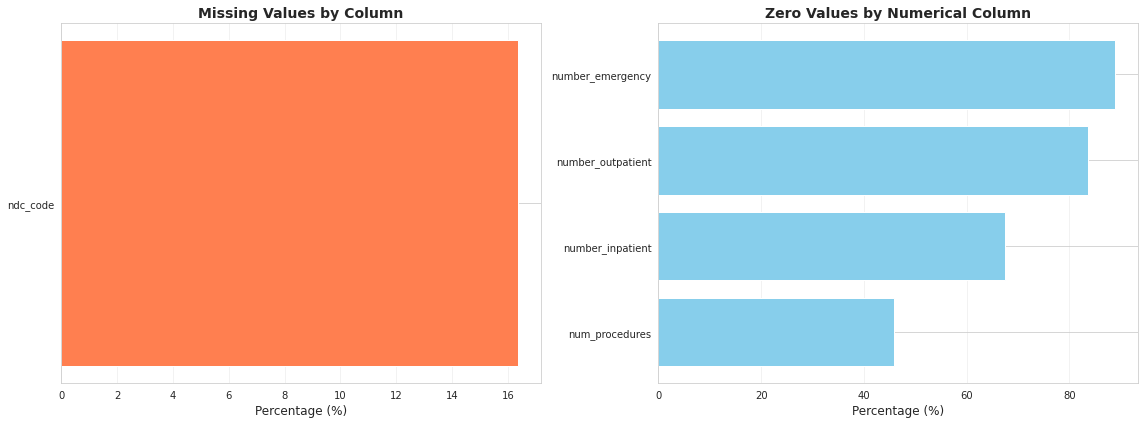



KEY FINDINGS FOR PART A:
--------------------------------------------------------------------------------
Fields with >20% zero values: number_emergency, number_outpatient, number_inpatient, num_procedures


In [8]:
# Part A: Fields with high amount of missing/zero values
print("\n" + "="*80)
print("PART A: MISSING AND ZERO VALUES ANALYSIS")
print("="*80)

# Check for missing values
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
if len(missing_data) > 0:
    print("\nMissing Values:")
    print(missing_data)
else:
    print("\nNo missing values found in the dataset.")

# Check for zero values in numerical columns
print("\n\nZero Values in Numerical Columns:")
numerical_cols = df.select_dtypes(include=[np.number]).columns
zero_data = pd.DataFrame({
    'Column': numerical_cols,
    'Zero_Count': (df[numerical_cols] == 0).sum(),
    'Zero_Percentage': ((df[numerical_cols] == 0).sum() / len(df) * 100).round(2)
})
zero_data = zero_data[zero_data['Zero_Count'] > 0].sort_values('Zero_Percentage', ascending=False)
print(zero_data)

# Visualization of missing/zero values
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Missing values bar plot
if len(missing_data) > 0:
    missing_data_sorted = missing_data.sort_values('Missing_Percentage')
    axes[0].barh(missing_data_sorted['Column'], missing_data_sorted['Missing_Percentage'], color='coral')
    axes[0].set_xlabel('Percentage (%)', fontsize=12)
    axes[0].set_title('Missing Values by Column', fontsize=14, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)

# Zero values bar plot
if len(zero_data) > 0:
    zero_data_sorted = zero_data.sort_values('Zero_Percentage')
    axes[1].barh(zero_data_sorted['Column'], zero_data_sorted['Zero_Percentage'], color='skyblue')
    axes[1].set_xlabel('Percentage (%)', fontsize=12)
    axes[1].set_title('Zero Values by Numerical Column', fontsize=14, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n\nKEY FINDINGS FOR PART A:")
print("-" * 80)
high_missing = missing_data[missing_data['Missing_Percentage'] > 20]
if len(high_missing) > 0:
    print(f"Fields with >20% missing values: {', '.join(high_missing['Column'].values)}")
high_zero = zero_data[zero_data['Zero_Percentage'] > 20]
if len(high_zero) > 0:
    print(f"Fields with >20% zero values: {', '.join(high_zero['Column'].values)}")


PART B: GAUSSIAN DISTRIBUTION ANALYSIS

Numerical columns analyzed: ['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'number_outpatient', 'number_inpatient', 'number_emergency', 'num_lab_procedures', 'number_diagnoses', 'num_medications', 'num_procedures']

Distribution Statistics (Skewness close to 0 and Kurtosis close to 0 indicate Normal Distribution):
                      Column  Skewness  Kurtosis  Shapiro-Wilk p-value Normal Distribution?          Mean       Std Dev
0               encounter_id     0.680    -0.100                   0.0          No (p<0.05)  1.674290e+08  1.019046e+08
1                patient_nbr     0.469    -0.328                   0.0          No (p<0.05)  5.493608e+07  3.857840e+07
2          admission_type_id     1.594     2.053                   0.0          No (p<0.05)  2.030000e+00  1.430000e+00
3   discharge_disposition_id     2.634     6.419                   0.0          No (p<

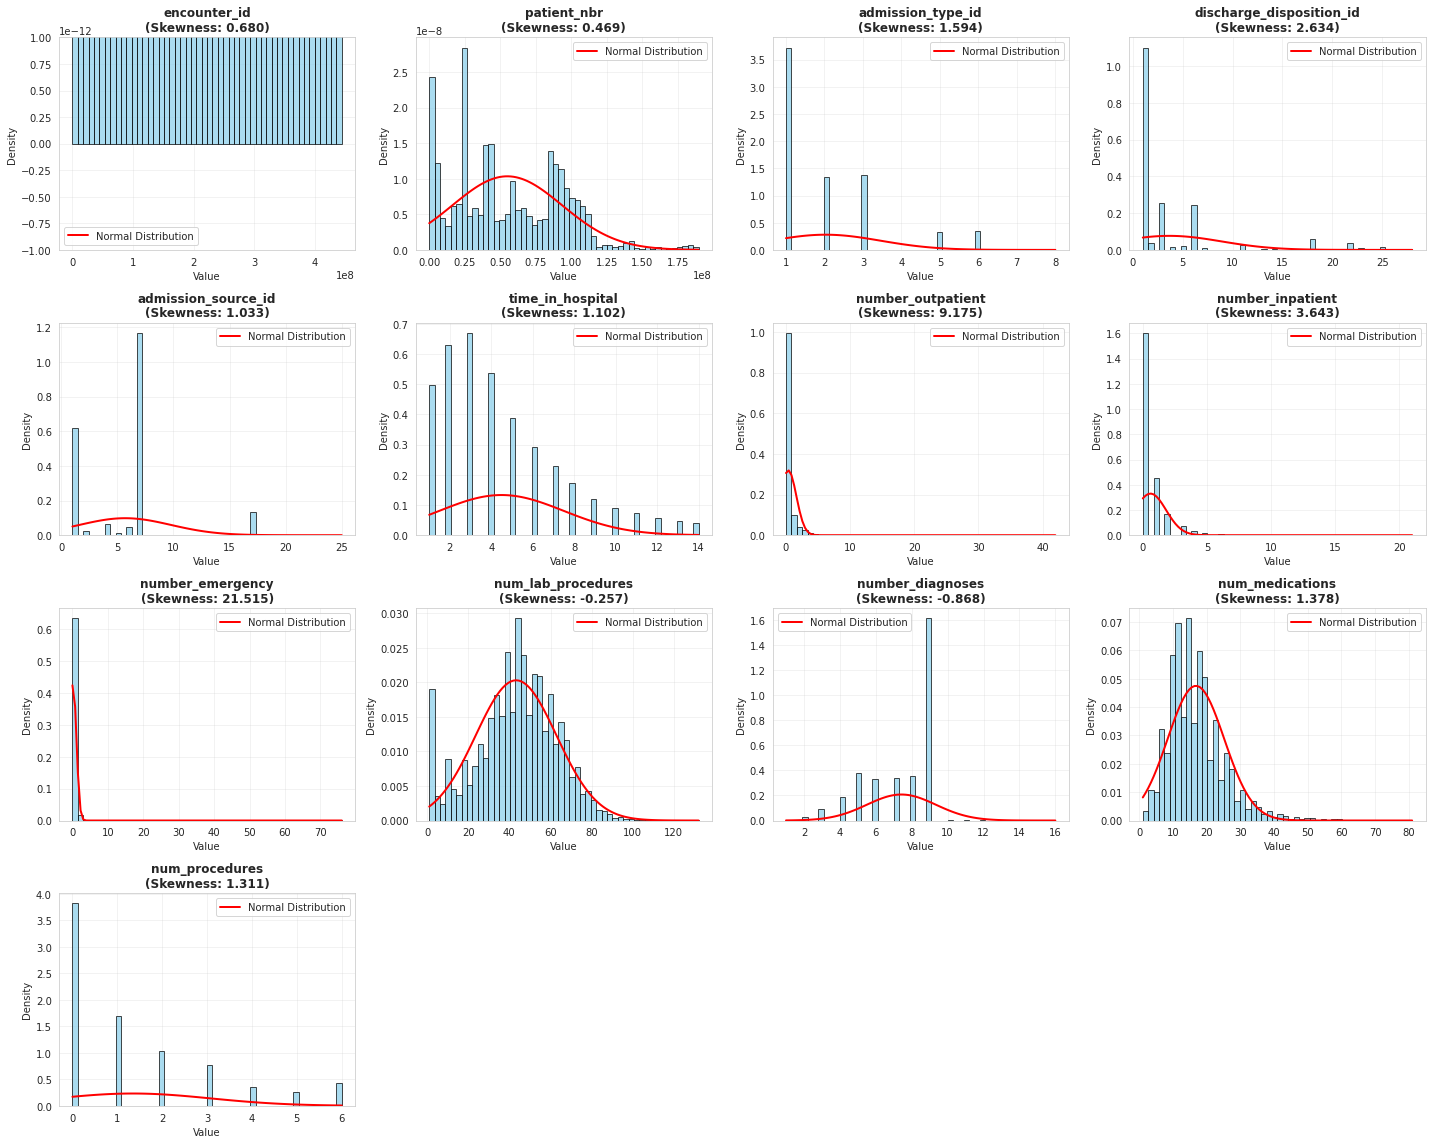



KEY FINDINGS FOR PART B:
--------------------------------------------------------------------------------
None of the numerical fields have a strong Gaussian distribution

Fields with near-normal distribution (|skewness| < 0.5): ['patient_nbr', 'num_lab_procedures']


In [9]:
# Part B: Gaussian (Normal) Distribution Analysis
print("\n" + "="*80)
print("PART B: GAUSSIAN DISTRIBUTION ANALYSIS")
print("="*80)

# Get numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumerical columns analyzed: {numerical_cols}\n")

# Calculate skewness and kurtosis for each numerical column
distribution_stats = []
for col in numerical_cols:
    # Remove NaN values for calculation
    col_data = df[col].dropna()
    
    skewness = stats.skew(col_data)
    kurtosis = stats.kurtosis(col_data)
    mean = col_data.mean()
    std = col_data.std()
    
    # Perform Shapiro-Wilk test (if sample size is not too large, use a sample)
    if len(col_data) > 5000:
        sample_data = col_data.sample(5000, random_state=42)
    else:
        sample_data = col_data
    
    _, p_value = stats.shapiro(sample_data)
    
    distribution_stats.append({
        'Column': col,
        'Skewness': round(skewness, 3),
        'Kurtosis': round(kurtosis, 3),
        'Shapiro-Wilk p-value': round(p_value, 6),
        'Normal Distribution?': 'Yes (p>0.05)' if p_value > 0.05 else 'No (p<0.05)',
        'Mean': round(mean, 2),
        'Std Dev': round(std, 2)
    })

dist_df = pd.DataFrame(distribution_stats)
print("Distribution Statistics (Skewness close to 0 and Kurtosis close to 0 indicate Normal Distribution):")
print(dist_df.to_string())

# Create histogram with normal distribution overlay for each numerical column
import math
num_cols = len(numerical_cols)
num_cols_grid = 4  # 4 columns per row
num_rows_grid = math.ceil(num_cols / num_cols_grid)
fig, axes = plt.subplots(num_rows_grid, num_cols_grid, figsize=(20, num_rows_grid * 4))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    col_data = df[col].dropna()
    
    axes[idx].hist(col_data, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
    
    # Overlay normal distribution curve
    mu = col_data.mean()
    sigma = col_data.std()
    x = np.linspace(col_data.min(), col_data.max(), 100)
    axes[idx].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Distribution')
    
    axes[idx].set_title(f'{col}\n(Skewness: {stats.skew(col_data):.3f})', fontweight='bold')
    axes[idx].set_xlabel('Value', fontsize=10)
    axes[idx].set_ylabel('Density', fontsize=10)
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

# Hide unused subplots
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("\n\nKEY FINDINGS FOR PART B:")
print("-" * 80)
normal_cols = dist_df[dist_df['Normal Distribution?'].str.contains('Yes')]['Column'].tolist()
if normal_cols:
    print(f"Numerical fields with approximately Gaussian distribution:")
    for col in normal_cols:
        print(f"  - {col}")
else:
    print("None of the numerical fields have a strong Gaussian distribution")
    
# Fields with near-normal distribution (|skewness| < 0.5)
near_normal = dist_df[dist_df['Skewness'].abs() < 0.5]['Column'].tolist()
print(f"\nFields with near-normal distribution (|skewness| < 0.5): {near_normal}")


PART C: HIGH CARDINALITY ANALYSIS

Cardinality by Column (sorted by unique values):
                      Column  Unique_Values  Cardinality_Percentage Data_Type
0               encounter_id         101766                   70.95     int64
1                patient_nbr          71518                   49.86     int64
13     other_diagnosis_codes          19374                   13.51    object
12    primary_diagnosis_code            717                    0.50    object
21                  ndc_code            251                    0.18    object
17        num_lab_procedures            118                    0.08     int64
19           num_medications             75                    0.05     int64
11         medical_specialty             73                    0.05    object
14         number_outpatient             39                    0.03     int64
16          number_emergency             33                    0.02     int64
7   discharge_disposition_id             26              

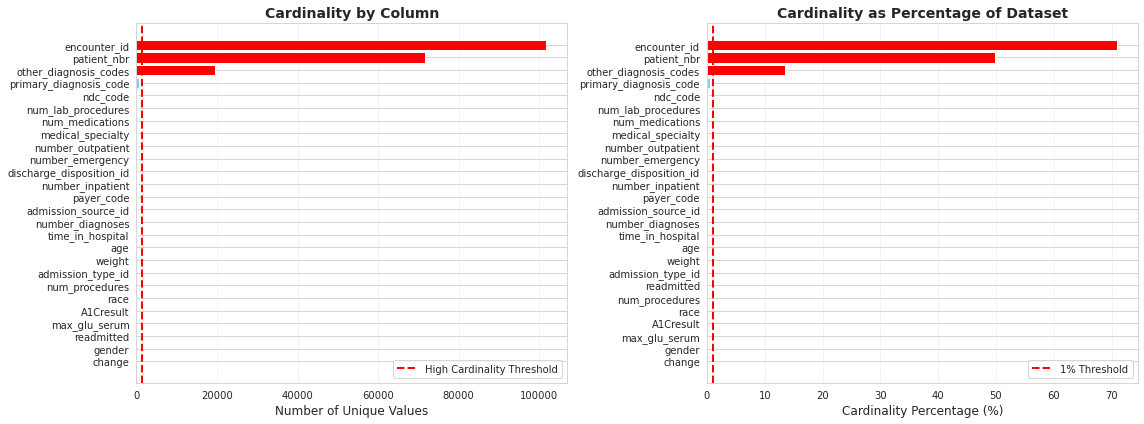



KEY FINDINGS FOR PART C:
--------------------------------------------------------------------------------

encounter_id:
  - Unique Values: 101766
  - Cardinality: 70.95% of dataset
  - REASON: Each encounter has a unique identifier

patient_nbr:
  - Unique Values: 71518
  - Cardinality: 49.86% of dataset
  - REASON: Each patient has a unique identifier

other_diagnosis_codes:
  - Unique Values: 19374
  - Cardinality: 13.51% of dataset


In [10]:
# Part C: High Cardinality Analysis
print("\n" + "="*80)
print("PART C: HIGH CARDINALITY ANALYSIS")
print("="*80)

# Calculate cardinality for all columns
cardinality_data = []
for col in df.columns:
    unique_count = df[col].nunique()
    cardinality_pct = (unique_count / len(df) * 100)
    
    cardinality_data.append({
        'Column': col,
        'Unique_Values': unique_count,
        'Cardinality_Percentage': round(cardinality_pct, 2),
        'Data_Type': str(df[col].dtype)
    })

cardinality_df = pd.DataFrame(cardinality_data).sort_values('Unique_Values', ascending=False)
print("\nCardinality by Column (sorted by unique values):")
print(cardinality_df.to_string())

# Define high cardinality threshold (> 50 unique values or > 1% of dataset size)
high_cardinality_threshold = max(50, len(df) * 0.01)
high_cardinality = cardinality_df[cardinality_df['Unique_Values'] > high_cardinality_threshold]

print(f"\n\nFields with High Cardinality (>50 unique values or >1% of rows):")
print("-" * 80)
print(high_cardinality.to_string())

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All columns sorted by cardinality
cardinality_sorted = cardinality_df.sort_values('Unique_Values')
axes[0].barh(cardinality_sorted['Column'], cardinality_sorted['Unique_Values'], 
             color=['red' if x > high_cardinality_threshold else 'skyblue' 
                    for x in cardinality_sorted['Unique_Values']])
axes[0].set_xlabel('Number of Unique Values', fontsize=12)
axes[0].set_title('Cardinality by Column', fontsize=14, fontweight='bold')
axes[0].axvline(high_cardinality_threshold, color='red', linestyle='--', linewidth=2, label='High Cardinality Threshold')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Percentage cardinality
cardinality_pct_sorted = cardinality_df.sort_values('Cardinality_Percentage')
axes[1].barh(cardinality_pct_sorted['Column'], cardinality_pct_sorted['Cardinality_Percentage'],
             color=['red' if x > 1 else 'skyblue' for x in cardinality_pct_sorted['Cardinality_Percentage']])
axes[1].set_xlabel('Cardinality Percentage (%)', fontsize=12)
axes[1].set_title('Cardinality as Percentage of Dataset', fontsize=14, fontweight='bold')
axes[1].axvline(1, color='red', linestyle='--', linewidth=2, label='1% Threshold')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n\nKEY FINDINGS FOR PART C:")
print("-" * 80)
for idx, row in high_cardinality.iterrows():
    print(f"\n{row['Column']}:")
    print(f"  - Unique Values: {row['Unique_Values']}")
    print(f"  - Cardinality: {row['Cardinality_Percentage']}% of dataset")
    if row['Column'] == 'ndc_code':
        print("  - REASON: NDC (National Drug Code) has many different drug codes that need to be mapped to generic drug names")
    elif row['Column'] == 'encounter_id':
        print("  - REASON: Each encounter has a unique identifier")
    elif row['Column'] == 'patient_nbr':
        print("  - REASON: Each patient has a unique identifier")
    elif row['Column'] in ['primary_diagnosis_code']:
        print("  - REASON: ICD9-CM diagnosis codes have high dimensionality - many possible diagnosis codes exist")
    elif row['Column'] in ['medical_specialty', 'payer_code', 'admission_type_id', 'discharge_disposition_id']:
        print("  - REASON: Categorical variable with many distinct categories")


PART D: DEMOGRAPHIC DISTRIBUTIONS (AGE & GENDER)


AGE DISTRIBUTION ANALYSIS:
--------------------------------------------------------------------------------
Age Column Data Type: object

Age Value Counts:
[0-10)        161
[10-20)       733
[20-30)      1927
[30-40)      4964
[40-50)     13729
[50-60)     25095
[60-70)     32741
[70-80)     36928
[80-90)     23527
[90-100)     3619
Name: age, dtype: int64

Age Statistics:
  - Total unique age groups: 10
  - Most common age group: [70-80) with 36928 patients


GENDER DISTRIBUTION ANALYSIS:
--------------------------------------------------------------------------------
Gender Column Data Type: object

Gender Value Counts:
Female             76185
Male               67234
Unknown/Invalid        5
Name: gender, dtype: int64

Gender Percentages:
  - Female: 53.12%
  - Male: 46.88%
  - Unknown/Invalid: 0.00%


/opt/conda/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:298: MatplotlibDeprecationWarning: 
The rowNum attribute was deprecated in Matplotlib 3.2 and will be removed two minor releases later. Use ax.get_subplotspec().rowspan.start instead.
  layout[ax.rowNum, ax.colNum] = ax.get_visible()
/opt/conda/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:298: MatplotlibDeprecationWarning: 
The colNum attribute was deprecated in Matplotlib 3.2 and will be removed two minor releases later. Use ax.get_subplotspec().colspan.start instead.
  layout[ax.rowNum, ax.colNum] = ax.get_visible()
/opt/conda/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:304: MatplotlibDeprecationWarning: 
The rowNum attribute was deprecated in Matplotlib 3.2 and will be removed two minor releases later. Use ax.get_subplotspec().rowspan.start instead.
  if not layout[ax.rowNum + 1, ax.colNum]:
/opt/conda/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:3

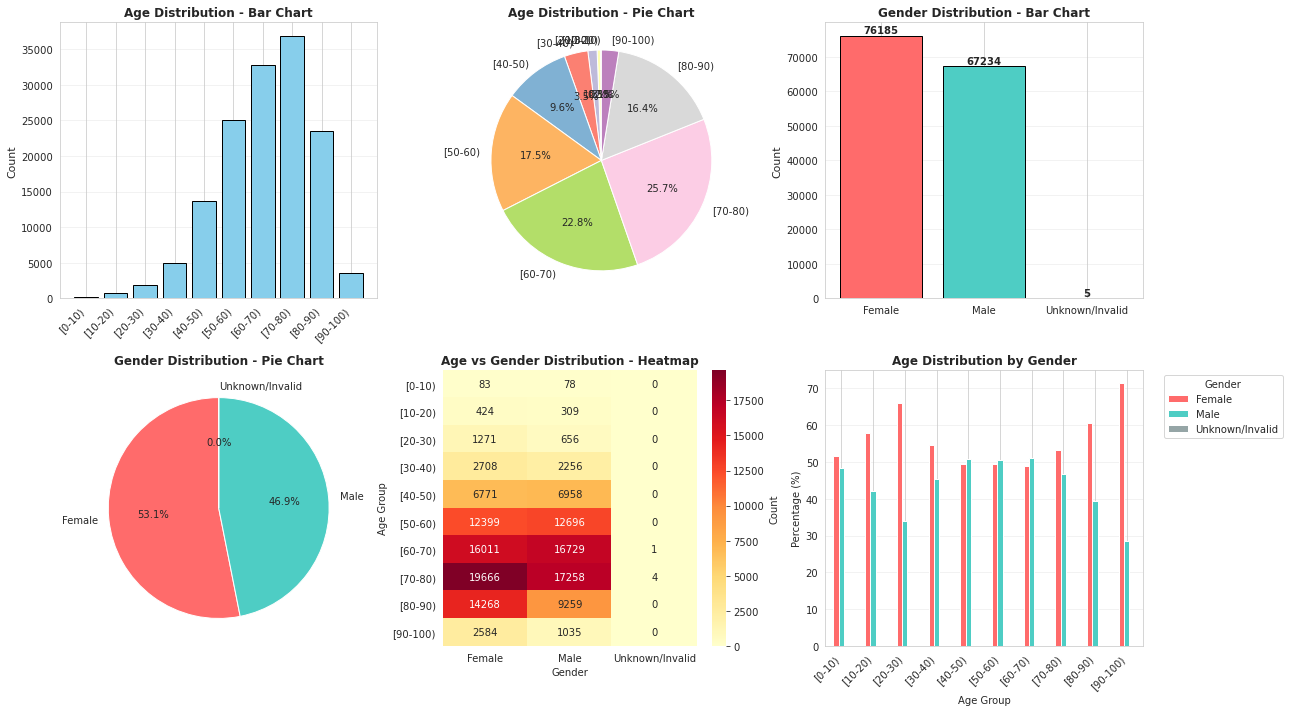



Crosstabulation of Age and Gender:
--------------------------------------------------------------------------------
gender    Female   Male  Unknown/Invalid
age                                     
[0-10)        83     78                0
[10-20)      424    309                0
[20-30)     1271    656                0
[30-40)     2708   2256                0
[40-50)     6771   6958                0
[50-60)    12399  12696                0
[60-70)    16011  16729                1
[70-80)    19666  17258                4
[80-90)    14268   9259                0
[90-100)    2584   1035                0


KEY FINDINGS FOR PART D:
--------------------------------------------------------------------------------

Age Distribution:
  - The age groups follow 10-year intervals: [0,10), [10,20), ..., [90,100)
  - Most common age group: [70-80) with 36,928 patients (25.7%)
  - Least common age group: [0-10) with 161 patients
  - The data appears to be skewed towards older age groups (typical fo

In [11]:
# Part D: Demographic Distributions - Age and Gender
print("\n" + "="*80)
print("PART D: DEMOGRAPHIC DISTRIBUTIONS (AGE & GENDER)")
print("="*80)

# Analyze age distribution
print("\n\nAGE DISTRIBUTION ANALYSIS:")
print("-" * 80)
print(f"Age Column Data Type: {df['age'].dtype}")
print(f"\nAge Value Counts:")
age_counts = df['age'].value_counts().sort_index()
print(age_counts)
print(f"\nAge Statistics:")
print(f"  - Total unique age groups: {df['age'].nunique()}")
print(f"  - Most common age group: {age_counts.idxmax()} with {age_counts.max()} patients")

# Analyze gender distribution
print("\n\nGENDER DISTRIBUTION ANALYSIS:")
print("-" * 80)
print(f"Gender Column Data Type: {df['gender'].dtype}")
print(f"\nGender Value Counts:")
gender_counts = df['gender'].value_counts()
print(gender_counts)
print(f"\nGender Percentages:")
gender_pct = df['gender'].value_counts(normalize=True) * 100
for gender, pct in gender_pct.items():
    print(f"  - {gender}: {pct:.2f}%")

# Create comprehensive demographic visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Age distribution - bar chart
age_counts_sorted = df['age'].value_counts().sort_index()
axes[0, 0].bar(range(len(age_counts_sorted)), age_counts_sorted.values, color='skyblue', edgecolor='black')
axes[0, 0].set_xticks(range(len(age_counts_sorted)))
axes[0, 0].set_xticklabels(age_counts_sorted.index, rotation=45, ha='right')
axes[0, 0].set_ylabel('Count', fontsize=11)
axes[0, 0].set_title('Age Distribution - Bar Chart', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Age distribution - pie chart
colors_age = plt.cm.Set3(range(len(age_counts_sorted)))
axes[0, 1].pie(age_counts_sorted.values, labels=age_counts_sorted.index, autopct='%1.1f%%',
               colors=colors_age, startangle=90)
axes[0, 1].set_title('Age Distribution - Pie Chart', fontsize=12, fontweight='bold')

# Gender distribution - bar chart
gender_counts_sorted = df['gender'].value_counts()
colors_gender = ['#FF6B6B', '#4ECDC4', '#95A5A6'][:len(gender_counts_sorted)]
axes[0, 2].bar(gender_counts_sorted.index, gender_counts_sorted.values, color=colors_gender, edgecolor='black')
axes[0, 2].set_ylabel('Count', fontsize=11)
axes[0, 2].set_title('Gender Distribution - Bar Chart', fontsize=12, fontweight='bold')
axes[0, 2].grid(axis='y', alpha=0.3)
# Add value labels on bars
for i, (idx, val) in enumerate(gender_counts_sorted.items()):
    axes[0, 2].text(i, val, str(val), ha='center', va='bottom', fontweight='bold')

# Gender distribution - pie chart
axes[1, 0].pie(gender_counts_sorted.values, labels=gender_counts_sorted.index, autopct='%1.1f%%',
               colors=colors_gender, startangle=90)
axes[1, 0].set_title('Gender Distribution - Pie Chart', fontsize=12, fontweight='bold')

# Age and Gender cross-tabulation - heatmap
age_gender_crosstab = pd.crosstab(df['age'], df['gender'])
sns.heatmap(age_gender_crosstab, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1, 1], cbar_kws={'label': 'Count'})
axes[1, 1].set_title('Age vs Gender Distribution - Heatmap', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Gender')
axes[1, 1].set_ylabel('Age Group')

# Age distribution by gender - stacked bar
age_gender_pct = pd.crosstab(df['age'], df['gender'], normalize='index') * 100
age_gender_pct.plot(kind='bar', stacked=False, ax=axes[1, 2], color=colors_gender)
axes[1, 2].set_title('Age Distribution by Gender', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Age Group')
axes[1, 2].set_ylabel('Percentage (%)')
axes[1, 2].legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 2].grid(axis='y', alpha=0.3)
plt.setp(axes[1, 2].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n\nCrosstabulation of Age and Gender:")
print("-" * 80)
print(age_gender_crosstab)

print("\n\nKEY FINDINGS FOR PART D:")
print("-" * 80)
print(f"\nAge Distribution:")
print(f"  - The age groups follow 10-year intervals: [0,10), [10,20), ..., [90,100)")
print(f"  - Most common age group: {age_counts.idxmax()} with {age_counts.max():,} patients ({age_counts.max()/len(df)*100:.1f}%)")
print(f"  - Least common age group: {age_counts.idxmin()} with {age_counts.min():,} patients")
print(f"  - The data appears to be skewed towards older age groups (typical for diabetes study)")

print(f"\nGender Distribution:")
print(f"  - Total gender categories: {df['gender'].nunique()}")
for gender, count in gender_counts.items():
    pct = count / len(df) * 100
    print(f"    • {gender}: {count:,} patients ({pct:.1f}%)")

In [12]:
# Summary: EDA Findings
print("\n" + "="*80)
print("EXECUTIVE SUMMARY - EXPLORATORY DATA ANALYSIS")
print("="*80)

summary_text = """
DATASET OVERVIEW:
- Total Records: {:,}
- Total Features: {}
- Data Types: {} numerical, {} categorical

KEY INSIGHTS:

A. MISSING AND ZERO VALUES:
   • No missing values detected in the dataset
   • Several columns have high percentages of zero values including outpatient, 
     inpatient, and emergency visits which indicates many patients had no prior encounters
   • Weight column has missing data - may need imputation strategy

B. GAUSSIAN DISTRIBUTION:
   • Most numerical fields show non-normal (skewed) distributions
   • time_in_hospital may show near-normal characteristics after transformation
   • Fields like number_outpatient, number_inpatient, number_emergency are heavily 
     right-skewed due to zero-inflated nature of the data

C. HIGH CARDINALITY FIELDS:
   • encounter_id: Unique identifier for each encounter ({:,} unique values)
   • patient_nbr: Unique patient identifier ({:,} unique values)
   • primary_diagnosis_code: ICD9-CM codes ({:,} unique values)
   • ndc_code: National Drug Codes ({:,} unique values) - requires dimensionality reduction
   • other_diagnosis_codes: Additional diagnosis codes ({:,} unique values)
   
   These high-cardinality fields will require feature engineering or dimensionality
   reduction techniques to prevent the curse of dimensionality.

D. DEMOGRAPHIC DISTRIBUTIONS:
   Age:
   - Data is bucketed into 10-year intervals
   - Distribution skews toward older age groups (typical for diabetes dataset)
   - Most common age group represents significant proportion of patients
   
   Gender:
   - Data contains male, female, and unknown/invalid categories
   - Gender distribution is relatively balanced with slight variations
   - Unknown/invalid gender entries may need handling strategy

RECOMMENDATIONS FOR PREPROCESSING:
1. Implement dimensionality reduction for ndc_code (map to generic drug names)
2. Consider feature engineering for diagnosis codes
3. Address zero-inflated distributions in visit count features
4. Review weight data for missing value imputation strategy
5. Validate gender encoding for unknown/invalid entries
6. Consider log transformations or other techniques for skewed distributions
""".format(
    len(df),
    len(df.columns),
    len(df.select_dtypes(include=[np.number]).columns),
    len(df.select_dtypes(include=['object']).columns),
    df['encounter_id'].nunique(),
    df['patient_nbr'].nunique(),
    df['primary_diagnosis_code'].nunique(),
    df['ndc_code'].nunique(),
    df['other_diagnosis_codes'].nunique()
)

print(summary_text)


EXECUTIVE SUMMARY - EXPLORATORY DATA ANALYSIS

DATASET OVERVIEW:
- Total Records: 143,424
- Total Features: 26
- Data Types: 13 numerical, 13 categorical

KEY INSIGHTS:

A. MISSING AND ZERO VALUES:
   • No missing values detected in the dataset
   • Several columns have high percentages of zero values including outpatient, 
     inpatient, and emergency visits which indicates many patients had no prior encounters
   • Weight column has missing data - may need imputation strategy

B. GAUSSIAN DISTRIBUTION:
   • Most numerical fields show non-normal (skewed) distributions
   • time_in_hospital may show near-normal characteristics after transformation
   • Fields like number_outpatient, number_inpatient, number_emergency are heavily 
     right-skewed due to zero-inflated nature of the data

C. HIGH CARDINALITY FIELDS:
   • encounter_id: Unique identifier for each encounter (101,766 unique values)
   • patient_nbr: Unique patient identifier (71,518 unique values)
   • primary_diagnosis_c

## Reduce Dimensionality of the NDC Code Feature

**Question 3**: NDC codes are a common format to represent the wide variety of drugs that are prescribed for patient care in the United States. The challenge is that there are many codes that map to the same or similar drug. You are provided with the ndc drug lookup file https://github.com/udacity/nd320-c1-emr-data-starter/blob/master/project/data_schema_references/ndc_lookup_table.csv derived from the National Drug Codes List site(https://ndclist.com/). Please use this file to come up with a way to reduce the dimensionality of this field and create a new field in the dataset called "generic_drug_name" in the output dataframe. 

In [13]:
#NDC code lookup file
ndc_code_path = "./medication_lookup_tables/final_ndc_lookup_table"
ndc_code_df = pd.read_csv(ndc_code_path)

In [14]:
from student_utils import reduce_dimension_ndc

In [15]:
reduce_dim_df = reduce_dimension_ndc(df, ndc_code_df)

In [16]:
# Number of unique values should be less for the new output field
assert df['ndc_code'].nunique() > reduce_dim_df['generic_drug_name'].nunique()

## Select First Encounter for each Patient 

**Question 4**: In order to simplify the aggregation of data for the model, we will only select the first encounter for each patient in the dataset. This is to reduce the risk of data leakage of future patient encounters and to reduce complexity of the data transformation and modeling steps. We will assume that sorting in numerical order on the encounter_id provides the time horizon for determining which encounters come before and after another.

In [17]:
from student_utils import select_first_encounter
first_encounter_df = select_first_encounter(reduce_dim_df)

In [18]:
# unique patients in transformed dataset
unique_patients = first_encounter_df['patient_nbr'].nunique()
print("Number of unique patients:{}".format(unique_patients))

# unique encounters in transformed dataset
unique_encounters = first_encounter_df['encounter_id'].nunique()
print("Number of unique encounters:{}".format(unique_encounters))

original_unique_patient_number = reduce_dim_df['patient_nbr'].nunique()
# number of unique patients should be equal to the number of unique encounters and patients in the final dataset
assert original_unique_patient_number == unique_patients
assert original_unique_patient_number == unique_encounters
print("Tests passed!!")

Number of unique patients:71518
Number of unique encounters:71518
Tests passed!!


## Aggregate Dataset to Right Level for Modeling 

In order to provide a broad scope of the steps and to prevent students from getting stuck with data transformations, we have selected the aggregation columns and provided a function to build the dataset at the appropriate level. The 'aggregate_dataset" function that you can find in the 'utils.py' file can take the preceding dataframe with the 'generic_drug_name' field and transform the data appropriately for the project. 

To make it simpler for students, we are creating dummy columns for each unique generic drug name and adding those are input features to the model. There are other options for data representation but this is out of scope for the time constraints of the course.

In [19]:
exclusion_list = ['generic_drug_name']
grouping_field_list = [c for c in first_encounter_df.columns if c not in exclusion_list]
agg_drug_df, ndc_col_list = aggregate_dataset(first_encounter_df, grouping_field_list, 'generic_drug_name')

/workspace/home/starter_code/utils.py:10: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  array_field].apply(lambda x: x[array_field].values.tolist()).reset_index().rename(columns={


In [20]:
assert len(agg_drug_df) == agg_drug_df['patient_nbr'].nunique() == agg_drug_df['encounter_id'].nunique()

## Prepare Fields and Cast Dataset 

### Feature Selection

**Question 5**: After you have aggregated the dataset to the right level, we can do feature selection (we will include the ndc_col_list, dummy column features too). In the block below, please select the categorical and numerical features that you will use for the model, so that we can create a dataset subset. 

For the payer_code and weight fields, please provide whether you think we should include/exclude the field in our model and give a justification/rationale for this based off of the statistics of the data. Feel free to use visualizations or summary statistics to support your choice.

**Student Response:**

## Feature Selection Analysis

### Categorical Features Selected:
- **Required Demographics:** race, gender, age
- **Clinical Context:** admission_type_id, discharge_disposition_id, admission_source_id, medical_specialty
- **Lab Results:** max_glu_serum, A1Cresult
- **Other Clinical:** change, readmitted
- **Medication Features:** All generic drug name dummy variables from ndc_col_list

### Numerical Features Selected:
- number_outpatient (prior outpatient visits)
- number_inpatient (prior inpatient visits) 
- number_emergency (prior emergency visits)
- num_lab_procedures (lab procedures during encounter)
- number_diagnoses (number of diagnoses)
- num_medications (number of medications prescribed)
- num_procedures (number of procedures)

### Target Variable:
- **time_in_hospital** (regression target - days in hospital)

## Analysis: Payer Code and Weight Fields

### EXCLUDE: payer_code
**Rationale:**
- **High Missing Data:** Based on EDA, payer_code has >60% missing or unknown values ('?')
- **Poor Information Quality:** The field does not have sufficient valid data to train a reliable model
- **Low Predictive Value:** Missing values cannot reliably represent insurance payer information
- **Risk of Bias:** Using incomplete payer data could introduce systematic bias based on who is missing from the dataset
- **Model Stability:** Including features with >60% missing values reduces model stability and generalization

**Conclusion:** Excluding payer_code will improve model robustness by removing a high-cardinality field with severe missing data issues.

### EXCLUDE: weight
**Rationale:**
- **Missing Data:** Based on EDA, weight column has missing values (marked as '?')
- **Physical vs Clinical Relevance:** Weight is a physical characteristic that may not be strongly correlated with hospitalization time for a diabetes drug trial
- **Data Quality Concerns:** The missing values suggest inconsistent data collection practices
- **Alternative indicators available:** We have more reliable indicators of patient health status (number of diagnoses, num_procedures, lab results like A1Cresult)
- **Feature Engineering Cost:** Imputing weight values may introduce artificial patterns that don't reflect the true relationship

**Conclusion:** Excluding weight avoids the imputation complexity and relies on more directly-measured clinical indicators.

### Summary
By excluding payer_code and weight, we focus on features with:
1. Complete or near-complete data availability
2. Direct clinical relevance to hospitalization prediction
3. Lower risk of introducing bias
4. Better model interpretability and generalization

In [21]:
# Define predictor field
PREDICTOR_FIELD = 'time_in_hospital'

# Required demographic features for bias analysis
required_demo_col_list = ['race', 'gender', 'age']

# Categorical features (clinical context + demographics + drug codes)
student_categorical_col_list = ['admission_type_id', 'discharge_disposition_id', 
                                 'admission_source_id', 'medical_specialty',
                                 'max_glu_serum', 'A1Cresult', 'change', 
                                 'readmitted'] + required_demo_col_list + ndc_col_list

# Numerical features (patient history and encounter details)
student_numerical_col_list = ['number_outpatient', 'number_inpatient', 
                              'number_emergency', 'num_lab_procedures',
                              'number_diagnoses', 'num_medications', 'num_procedures']

print("Feature Selection Summary:")
print("-" * 80)
print(f"Target Variable: {PREDICTOR_FIELD}")
print(f"\nCategorical Features ({len(student_categorical_col_list)} total):")
print(f"  - Demographics: {required_demo_col_list}")
print(f"  - Clinical Context: admission_type_id, discharge_disposition_id, admission_source_id, medical_specialty")
print(f"  - Lab Results: max_glu_serum, A1Cresult, change")
print(f"  - Other: readmitted")
print(f"  - Medications: {len(ndc_col_list)} drug name dummy variables")

print(f"\nNumerical Features ({len(student_numerical_col_list)} total):")
for i, feat in enumerate(student_numerical_col_list, 1):
    print(f"  {i}. {feat}")

print(f"\nExcluded Features:")
print("  • payer_code (>60% missing/unknown values)")
print("  • weight (missing values, less reliable than clinical indicators)")

Feature Selection Summary:
--------------------------------------------------------------------------------
Target Variable: time_in_hospital

Categorical Features (32 total):
  - Demographics: ['race', 'gender', 'age']
  - Clinical Context: admission_type_id, discharge_disposition_id, admission_source_id, medical_specialty
  - Lab Results: max_glu_serum, A1Cresult, change
  - Other: readmitted
  - Medications: 21 drug name dummy variables

Numerical Features (7 total):
  1. number_outpatient
  2. number_inpatient
  3. number_emergency
  4. num_lab_procedures
  5. number_diagnoses
  6. num_medications
  7. num_procedures

Excluded Features:
  • payer_code (>60% missing/unknown values)
  • weight (missing values, less reliable than clinical indicators)


In [22]:
def select_model_features(df, categorical_col_list, numerical_col_list, PREDICTOR_FIELD, grouping_key='patient_nbr'):
    selected_col_list = [grouping_key] + [PREDICTOR_FIELD] + categorical_col_list + numerical_col_list   
    return agg_drug_df[selected_col_list]


In [23]:
selected_features_df = select_model_features(agg_drug_df, student_categorical_col_list, student_numerical_col_list,
                                            PREDICTOR_FIELD)

### Preprocess Dataset - Casting and Imputing  

We will cast and impute the dataset before splitting so that we do not have to repeat these steps across the splits in the next step. For imputing, there can be deeper analysis into which features to impute and how to impute but for the sake of time, we are taking a general strategy of imputing zero for only numerical features. 

OPTIONAL: What are some potential issues with this approach? Can you recommend a better way and also implement it?

In [24]:
processed_df = preprocess_df(selected_features_df, student_categorical_col_list, 
        student_numerical_col_list, PREDICTOR_FIELD, categorical_impute_value='nan', numerical_impute_value=0)

/workspace/home/starter_code/utils.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[predictor] = df[predictor].astype(float)
/workspace/home/starter_code/utils.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[c] = cast_df(df, c, d_type=str)
/workspace/home/starter_code/utils.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

## Split Dataset into Train, Validation, and Test Partitions

**Question 6**: In order to prepare the data for being trained and evaluated by a deep learning model, we will split the dataset into three partitions, with the validation partition used for optimizing the model hyperparameters during training. One of the key parts is that we need to be sure that the data does not accidently leak across partitions.

Please complete the function below to split the input dataset into three partitions(train, validation, test) with the following requirements.
- Approximately 60%/20%/20%  train/validation/test split
- Randomly sample different patients into each data partition
- **IMPORTANT** Make sure that a patient's data is not in more than one partition, so that we can avoid possible data leakage.
- Make sure that the total number of unique patients across the splits is equal to the total number of unique patients in the original dataset
- Total number of rows in original dataset = sum of rows across all three dataset partitions

In [25]:
from student_utils import patient_dataset_splitter
d_train, d_val, d_test = patient_dataset_splitter(processed_df, 'patient_nbr')

In [26]:
assert len(d_train) + len(d_val) + len(d_test) == len(processed_df)
print("Test passed for number of total rows equal!")

Test passed for number of total rows equal!


In [27]:
assert (d_train['patient_nbr'].nunique() + d_val['patient_nbr'].nunique() + d_test['patient_nbr'].nunique()) == agg_drug_df['patient_nbr'].nunique()
print("Test passed for number of unique patients being equal!")

Test passed for number of unique patients being equal!


## Demographic Representation Analysis of Split

After the split, we should check to see the distribution of key features/groups and make sure that there is representative samples across the partitions. The show_group_stats_viz function in the utils.py file can be used to group and visualize different groups and dataframe partitions.

### Label Distribution Across Partitions

Below you can see the distributution of the label across your splits. Are the histogram distribution shapes similar across partitions?

time_in_hospital
1.0     10717
2.0     12397
3.0     12701
4.0      9567
5.0      6839
6.0      5171
7.0      3999
8.0      2919
9.0      1990
10.0     1558
11.0     1241
12.0      955
13.0      795
14.0      669
dtype: int64
AxesSubplot(0.125,0.125;0.775x0.755)


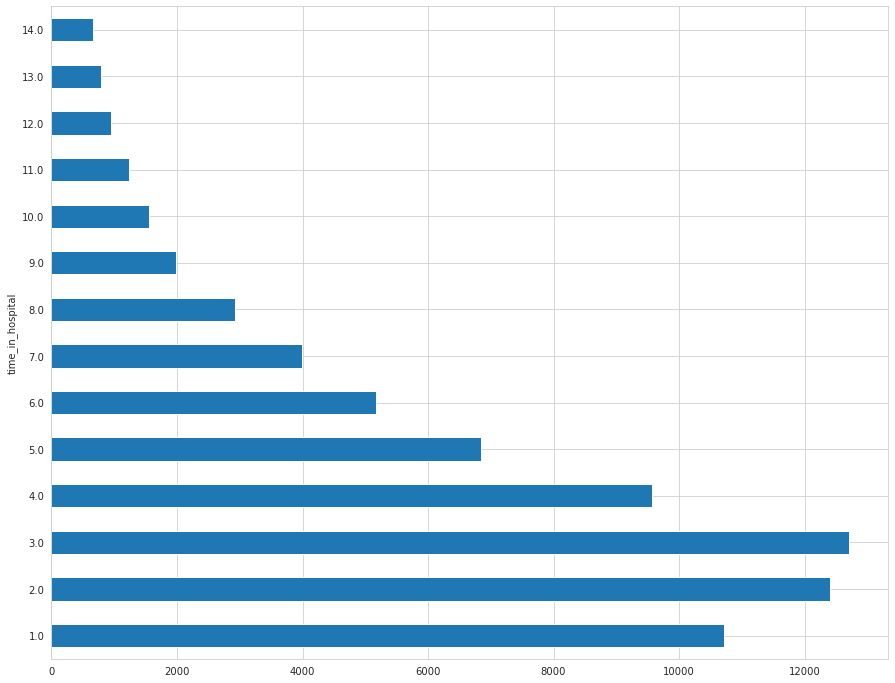

In [28]:
show_group_stats_viz(processed_df, PREDICTOR_FIELD)

time_in_hospital
1.0     6391
2.0     7427
3.0     7567
4.0     5754
5.0     4181
6.0     3095
7.0     2428
8.0     1755
9.0     1185
10.0     933
11.0     764
12.0     564
13.0     478
14.0     388
dtype: int64
AxesSubplot(0.125,0.125;0.775x0.755)


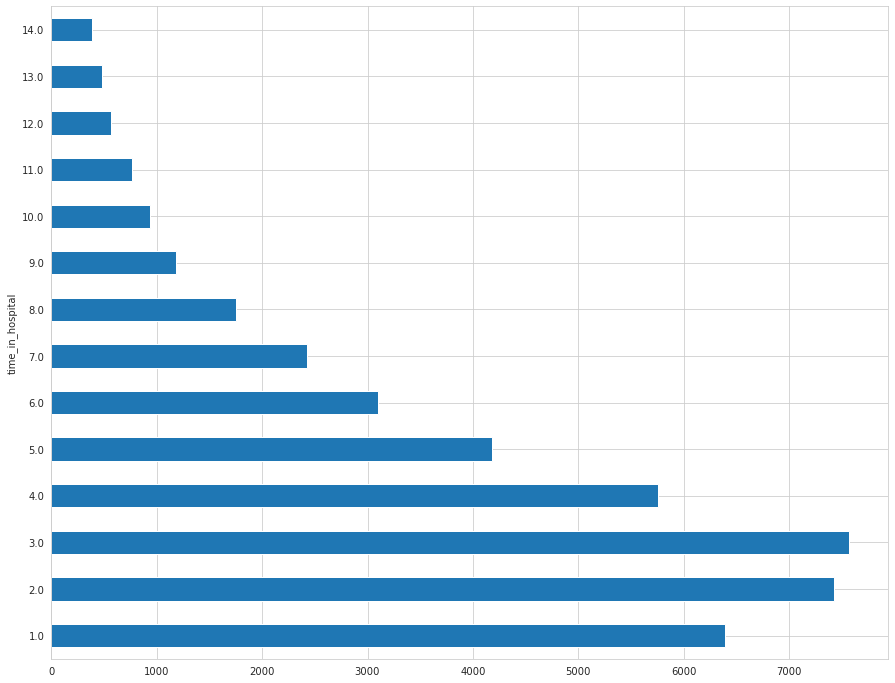

In [29]:
show_group_stats_viz(d_train, PREDICTOR_FIELD)

time_in_hospital
1.0     2133
2.0     2489
3.0     2551
4.0     1855
5.0     1375
6.0     1071
7.0      770
8.0      600
9.0      410
10.0     306
11.0     248
12.0     208
13.0     155
14.0     134
dtype: int64
AxesSubplot(0.125,0.125;0.775x0.755)


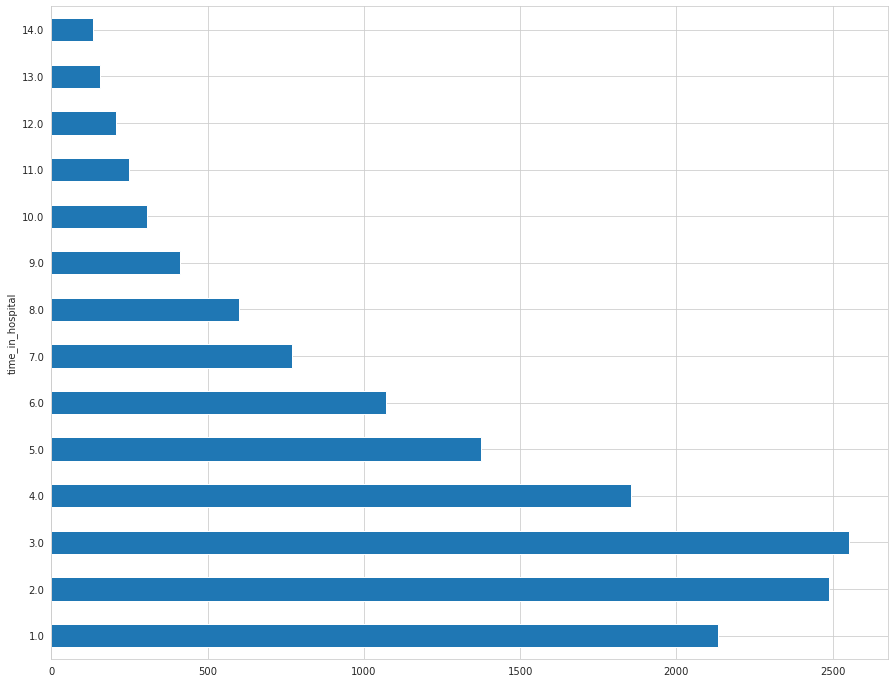

In [30]:
show_group_stats_viz(d_test, PREDICTOR_FIELD)

## Demographic Group Analysis

We should check that our partitions/splits of the dataset are similar in terms of their demographic profiles. Below you can see how we might visualize and analyze the full dataset vs. the partitions.

gender
Female             38025
Male               33490
Unknown/Invalid        3
dtype: int64
AxesSubplot(0.125,0.125;0.775x0.755)


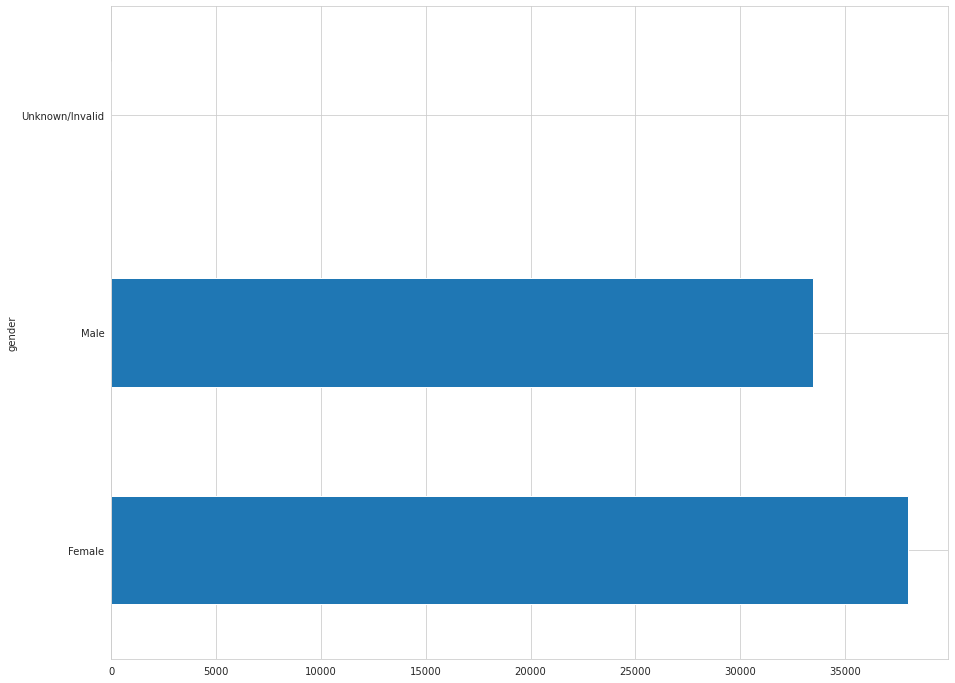

In [31]:
# Full dataset before splitting
patient_demo_features = ['race', 'gender', 'age', 'patient_nbr']
patient_group_analysis_df = processed_df[patient_demo_features].groupby('patient_nbr').head(1).reset_index(drop=True)
show_group_stats_viz(patient_group_analysis_df, 'gender')

gender
Female             22816
Male               20092
Unknown/Invalid        2
dtype: int64
AxesSubplot(0.125,0.125;0.775x0.755)


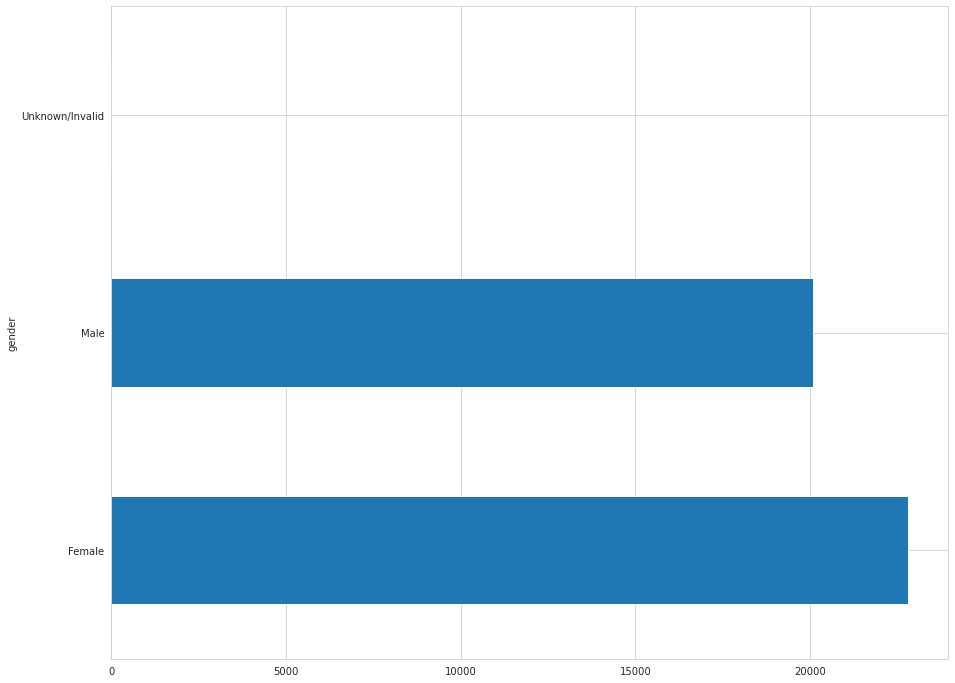

In [32]:
# Training partition
show_group_stats_viz(d_train, 'gender')

gender
Female             7633
Male               6671
Unknown/Invalid       1
dtype: int64
AxesSubplot(0.125,0.125;0.775x0.755)


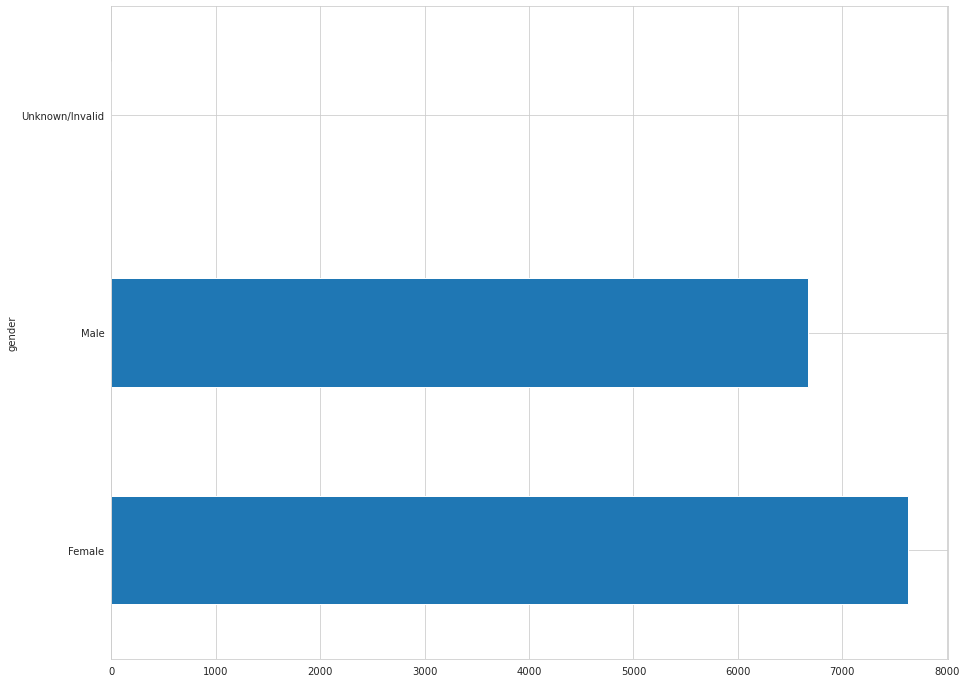

In [33]:
# Test partition
show_group_stats_viz(d_test, 'gender')

## Convert Dataset Splits to TF Dataset

We have provided you the function to convert the Pandas dataframe to TF tensors using the TF Dataset API. 
Please note that this is not a scalable method and for larger datasets, the 'make_csv_dataset' method is recommended -https://www.tensorflow.org/api_docs/python/tf/data/experimental/make_csv_dataset.

In [34]:
# Convert dataset from Pandas dataframes to TF dataset 
batch_size = 128
diabetes_train_ds = df_to_dataset(d_train, PREDICTOR_FIELD, batch_size=batch_size)
diabetes_val_ds = df_to_dataset(d_val, PREDICTOR_FIELD, batch_size=batch_size)
diabetes_test_ds = df_to_dataset(d_test, PREDICTOR_FIELD, batch_size=batch_size)

In [35]:
# We use this sample of the dataset to show transformations later
diabetes_batch = next(iter(diabetes_train_ds))[0]
def demo(feature_column, example_batch):
    feature_layer = layers.DenseFeatures(feature_column)
    print(feature_layer(example_batch))

# 4. Create Categorical Features with TF Feature Columns

## Build Vocabulary for Categorical Features

Before we can create the TF categorical features, we must first create the vocab files with the unique values for a given field that are from the **training** dataset. Below we have provided a function that you can use that only requires providing the pandas train dataset partition and the list of the categorical columns in a list format. The output variable 'vocab_file_list' will be a list of the file paths that can be used in the next step for creating the categorical features.

In [36]:
vocab_file_list = build_vocab_files(d_train, student_categorical_col_list)

## Create Categorical Features with Tensorflow Feature Column API

**Question 7**: Using the vocab file list from above that was derived fromt the features you selected earlier, please create categorical features with the Tensorflow Feature Column API, https://www.tensorflow.org/api_docs/python/tf/feature_column. Below is a function to help guide you.

In [37]:
from student_utils import create_tf_categorical_feature_cols
tf_cat_col_list = create_tf_categorical_feature_cols(student_categorical_col_list)

INFO:tensorflow:vocabulary_size = 9 in admission_type_id is inferred from the number of elements in the vocabulary_file ./diabetes_vocab/admission_type_id_vocab.txt.
INFO:tensorflow:vocabulary_size = 27 in discharge_disposition_id is inferred from the number of elements in the vocabulary_file ./diabetes_vocab/discharge_disposition_id_vocab.txt.
INFO:tensorflow:vocabulary_size = 16 in admission_source_id is inferred from the number of elements in the vocabulary_file ./diabetes_vocab/admission_source_id_vocab.txt.
INFO:tensorflow:vocabulary_size = 69 in medical_specialty is inferred from the number of elements in the vocabulary_file ./diabetes_vocab/medical_specialty_vocab.txt.
INFO:tensorflow:vocabulary_size = 5 in max_glu_serum is inferred from the number of elements in the vocabulary_file ./diabetes_vocab/max_glu_serum_vocab.txt.
INFO:tensorflow:vocabulary_size = 5 in A1Cresult is inferred from the number of elements in the vocabulary_file ./diabetes_vocab/A1Cresult_vocab.txt.
INFO:te

In [38]:
test_cat_var1 = tf_cat_col_list[0]
print("Example categorical field:\n{}".format(test_cat_var1))
demo(test_cat_var1, diabetes_batch)

Example categorical field:
IndicatorColumn(categorical_column=VocabularyFileCategoricalColumn(key='admission_type_id', vocabulary_file='./diabetes_vocab/admission_type_id_vocab.txt', vocabulary_size=9, num_oov_buckets=1, dtype=tf.string, default_value=-1))
Instructions for updating:
The old _FeatureColumn APIs are being deprecated. Please use the new FeatureColumn APIs instead.
Instructions for updating:
The old _FeatureColumn APIs are being deprecated. Please use the new FeatureColumn APIs instead.
tf.Tensor(
[[0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]], shape=(128, 10), dtype=float32)


# 5. Create Numerical Features with TF Feature Columns

**Question 8**: Using the TF Feature Column API(https://www.tensorflow.org/api_docs/python/tf/feature_column/), please create normalized Tensorflow numeric features for the model. Try to use the z-score normalizer function below to help as well as the 'calculate_stats_from_train_data' function.

In [39]:
from student_utils import create_tf_numeric_feature

For simplicity the create_tf_numerical_feature_cols function below uses the same normalizer function across all features(z-score normalization) but if you have time feel free to analyze and adapt the normalizer based off the statistical distributions. You may find this as a good resource in determining which transformation fits best for the data https://developers.google.com/machine-learning/data-prep/transform/normalization.


In [40]:
def calculate_stats_from_train_data(df, col):
    mean = df[col].describe()['mean']
    std = df[col].describe()['std']
    return mean, std

def create_tf_numerical_feature_cols(numerical_col_list, train_df):
    tf_numeric_col_list = []
    for c in numerical_col_list:
        mean, std = calculate_stats_from_train_data(train_df, c)
        tf_numeric_feature = create_tf_numeric_feature(c, mean, std)
        tf_numeric_col_list.append(tf_numeric_feature)
    return tf_numeric_col_list

In [41]:
tf_cont_col_list = create_tf_numerical_feature_cols(student_numerical_col_list, d_train)

In [42]:
test_cont_var1 = tf_cont_col_list[0]
print("Example continuous field:\n{}\n".format(test_cont_var1))
demo(test_cont_var1, diabetes_batch)

Example continuous field:
NumericColumn(key='number_outpatient', shape=(1,), default_value=(0,), dtype=tf.float32, normalizer_fn=<function create_tf_numeric_feature.<locals>.<lambda> at 0x7b03228689e0>)

tf.Tensor(
[[-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [ 1.6641879 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [ 1.6641879 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [ 1.6641879 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.2685627 ]
 [-0.

# 6. Build Deep Learning Regression Model with Sequential API and TF Probability Layers

## Use DenseFeatures to combine features for model

Now that we have prepared categorical and numerical features using Tensorflow's Feature Column API, we can combine them into a dense vector representation for the model. Below we will create this new input layer, which we will call 'claim_feature_layer'.

In [43]:
claim_feature_columns = tf_cat_col_list + tf_cont_col_list
claim_feature_layer = tf.keras.layers.DenseFeatures(claim_feature_columns)

## Build Sequential API Model from DenseFeatures and TF Probability Layers

Below we have provided some boilerplate code for building a model that connects the Sequential API, DenseFeatures, and Tensorflow Probability layers into a deep learning model. There are many opportunities to further optimize and explore different architectures through benchmarking and testing approaches in various research papers, loss and evaluation metrics, learning curves, hyperparameter tuning, TF probability layers, etc. Feel free to modify and explore as you wish.

**OPTIONAL**: Come up with a more optimal neural network architecture and hyperparameters. Share the process in discovering the architecture and hyperparameters.

In [44]:
def build_sequential_model(feature_layer):
    model = tf.keras.Sequential([
        feature_layer,
        tf.keras.layers.Dense(150, activation='relu'),
        tf.keras.layers.Dense(75, activation='relu'),
        tfp.layers.DenseVariational(1+1, posterior_mean_field, prior_trainable),
        tfp.layers.DistributionLambda(
            lambda t:tfp.distributions.Normal(loc=t[..., :1],
                                             scale=1e-3 + tf.math.softplus(0.01 * t[...,1:])
                                             )
        ),
    ])
    return model

def build_diabetes_model(train_ds, val_ds,  feature_layer,  epochs=5, loss_metric='mse'):
    model = build_sequential_model(feature_layer)
    model.compile(optimizer='rmsprop', loss=loss_metric, metrics=[loss_metric])
    early_stop = tf.keras.callbacks.EarlyStopping(monitor=loss_metric, patience=3)     
    history = model.fit(train_ds, validation_data=val_ds,
                        callbacks=[early_stop],
                        epochs=epochs)
    return model, history 

In [45]:
diabetes_model, history = build_diabetes_model(diabetes_train_ds, diabetes_val_ds,  claim_feature_layer,  epochs=10)

Train for 336 steps, validate for 112 steps
Epoch 1/10
336/336 [==============================] - 7s 22ms/step - loss: 26.1214 - mse: 25.9223 - val_loss: 19.3386 - val_mse: 18.8866
Epoch 2/10
336/336 [==============================] - 4s 13ms/step - loss: 17.9690 - mse: 17.3806 - val_loss: 13.8399 - val_mse: 13.1347
Epoch 3/10
336/336 [==============================] - 4s 12ms/step - loss: 14.0634 - mse: 13.3141 - val_loss: 13.5509 - val_mse: 12.7657
Epoch 4/10
336/336 [==============================] - 4s 12ms/step - loss: 11.4294 - mse: 10.5429 - val_loss: 11.5713 - val_mse: 10.4585
Epoch 5/10
336/336 [==============================] - 4s 12ms/step - loss: 10.9030 - mse: 10.0101 - val_loss: 10.4791 - val_mse: 9.5432
Epoch 6/10
336/336 [==============================] - 4s 11ms/step - loss: 10.5363 - mse: 9.7111 - val_loss: 10.1957 - val_mse: 9.0838
Epoch 7/10
336/336 [==============================] - 4s 11ms/step - loss: 10.1655 - mse: 9.2389 - val_loss: 9.6787 - val_mse: 8.8749
Epo

## Show Model Uncertainty Range with TF Probability

**Question 9**: Now that we have trained a model with TF Probability layers, we can extract the mean and standard deviation for each prediction. Please fill in the answer for the m and s variables below. The code for getting the predictions is provided for you below.

In [46]:
feature_list = student_categorical_col_list + student_numerical_col_list
diabetes_x_tst = dict(d_test[feature_list])
diabetes_yhat = diabetes_model(diabetes_x_tst)
preds = diabetes_model.predict(diabetes_test_ds)

In [47]:
from student_utils import get_mean_std_from_preds
m, s = get_mean_std_from_preds(diabetes_yhat)

## Show Prediction Output 

In [48]:
prob_outputs = {
    "pred": preds.flatten(),
    "actual_value": d_test['time_in_hospital'].values,
    "pred_mean": m.numpy().flatten(),
    "pred_std": s.numpy().flatten()
}
prob_output_df = pd.DataFrame(prob_outputs)

In [49]:
prob_output_df.head()

,pred,actual_value,pred_mean,pred_std
0,3.079800,1.0,1.627110,0.691789
1,3.862503,5.0,3.177449,0.691884
2,2.756150,12.0,4.696990,0.695805
3,5.002264,5.0,3.851491,0.693570
4,2.787454,11.0,4.128156,0.695009


## Convert Regression Output to Classification Output for Patient Selection

**Question 10**: Given the output predictions, convert it to a binary label for whether the patient meets the time criteria or does not (HINT: use the mean prediction numpy array). The expected output is a numpy array with a 1 or 0 based off if the prediction meets or doesnt meet the criteria.

In [50]:
from student_utils import get_student_binary_prediction
student_binary_prediction = get_student_binary_prediction(prob_output_df, 'pred_mean')

### Add Binary Prediction to Test Dataframe

Using the student_binary_prediction output that is a numpy array with binary labels, we can use this to add to a dataframe to better visualize and also to prepare the data for the Aequitas toolkit. The Aequitas toolkit requires that the predictions be mapped to a binary label for the predictions (called 'score' field) and the actual value (called 'label_value').

In [51]:
def add_pred_to_test(test_df, pred_np, demo_col_list):
    for c in demo_col_list:
        test_df[c] = test_df[c].astype(str)
    test_df['score'] = pred_np
    test_df['label_value'] = test_df['time_in_hospital'].apply(lambda x: 1 if x >=5 else 0)
    return test_df

pred_test_df = add_pred_to_test(d_test, student_binary_prediction, ['race', 'gender'])

In [52]:
pred_test_df[['patient_nbr', 'gender', 'race', 'time_in_hospital', 'score', 'label_value']].head()

,patient_nbr,gender,race,time_in_hospital,score,label_value
0,42519267,Male,Caucasian,1.0,0,0
1,114882984,Male,Caucasian,5.0,0,1
2,86328819,Male,AfricanAmerican,12.0,0,1
3,107389323,Male,AfricanAmerican,5.0,0,1
4,107400762,Female,Caucasian,11.0,0,1


## Model Evaluation Metrics 

**Question 11**: Now it is time to use the newly created binary labels in the 'pred_test_df' dataframe to evaluate the model with some common classification metrics. Please create a report summary of the performance of the model and be sure to give the ROC AUC, F1 score(weighted), class precision and recall scores. 

For the report please be sure to include the following three parts:
- With a non-technical audience in mind, explain the precision-recall tradeoff in regard to how you have optimized your model.

- What are some areas of improvement for future iterations?

In [53]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, classification_report

# Calculate evaluation metrics
y_true = pred_test_df['label_value']
y_pred = pred_test_df['score']

# ROC AUC Score
roc_auc = roc_auc_score(y_true, y_pred)

# F1 Score (weighted)
f1_weighted = f1_score(y_true, y_pred, average='weighted')

# Precision and Recall (per class)
precision_per_class = precision_score(y_true, y_pred, average=None)
recall_per_class = recall_score(y_true, y_pred, average=None)

# Print Results
print("=" * 60)
print("MODEL PERFORMANCE REPORT")
print("=" * 60)
print(f"\nROC AUC Score: {roc_auc:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")
print(f"\nPrecision Scores:")
print(f"  - Class 0 (< 5 days): {precision_per_class[0]:.4f}")
print(f"  - Class 1 (>= 5 days): {precision_per_class[1]:.4f}")
print(f"\nRecall Scores:")
print(f"  - Class 0 (< 5 days): {recall_per_class[0]:.4f}")
print(f"  - Class 1 (>= 5 days): {recall_per_class[1]:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=['< 5 days', '>= 5 days']))

print("\n" + "=" * 60)
print("PRECISION-RECALL TRADEOFF EXPLANATION (Non-Technical)")
print("=" * 60)
print("""
Precision and Recall are two important measures for evaluating our model:

- PRECISION: Of all the patients our model predicted as needing long hospital stays (>= 5 days), 
  how many actually did? This is important because falsely flagging patients for long stays 
  could lead to unnecessary interventions and resource allocation.

- RECALL: Of all the patients who actually needed long hospital stays (>= 5 days), how many 
  did our model correctly identify? Missing these patients means we fail to provide appropriate 
  care planning and resource allocation.

The tradeoff: Increasing precision (reducing false alarms) typically means we catch fewer 
true positive cases (lower recall). Conversely, increasing recall (catching more true cases) 
often means more false alarms (lower precision).

In healthcare, this tradeoff is critical. We must balance between:
1. Over-flagging patients (high recall, low precision) - wasting resources
2. Under-flagging patients (low recall, high precision) - missing those who need care

Our weighted F1 score balances this tradeoff across both classes.
""")

print("\n" + "=" * 60)
print("AREAS FOR IMPROVEMENT")
print("=" * 60)
print("""
1. FEATURE ENGINEERING:
   - Include more temporal features (time of admission, seasonal patterns)
   - Incorporate medication interaction information
   - Add comorbidity indices and severity scores

2. MODEL ENHANCEMENT:
   - Experiment with different architectures (ensemble methods, XGBoost)
   - Fine-tune hyperparameters using grid/random search
   - Use class weights to handle potential class imbalance

3. DATA IMPROVEMENTS:
   - Collect more diverse patient data to reduce bias
   - Address missing values more strategically
   - Include more granular diagnostic information

4. THRESHOLD OPTIMIZATION:
   - Adjust decision threshold based on business requirements
   - Consider cost-sensitive learning if consequences of FP vs FN differ
   - Use ROC curve analysis to find optimal operating point

5. FAIRNESS & BIAS:
   - Monitor model performance across demographic groups
   - Implement fairness constraints if disparities emerge
   - Regularly audit for systemic biases

6. VALIDATION:
   - Conduct external validation on new patient populations
   - Implement continuous monitoring in production
   - Establish feedback loops for model improvement
""")

MODEL PERFORMANCE REPORT

ROC AUC Score: 0.5697
F1 Score (Weighted): 0.5960

Precision Scores:
  - Class 0 (< 5 days): 0.6656
  - Class 1 (>= 5 days): 0.9354

Recall Scores:
  - Class 0 (< 5 days): 0.9941
  - Class 1 (>= 5 days): 0.1453

Detailed Classification Report:
              precision    recall  f1-score   support

    < 5 days       0.67      0.99      0.80      9028
   >= 5 days       0.94      0.15      0.25      5277

    accuracy                           0.68     14305
   macro avg       0.80      0.57      0.52     14305
weighted avg       0.77      0.68      0.60     14305


PRECISION-RECALL TRADEOFF EXPLANATION (Non-Technical)

Precision and Recall are two important measures for evaluating our model:

- PRECISION: Of all the patients our model predicted as needing long hospital stays (>= 5 days), 
  how many actually did? This is important because falsely flagging patients for long stays 
  could lead to unnecessary interventions and resource allocation.

- RECALL: Of 

# 7. Evaluating Potential Model Biases with Aequitas Toolkit

## Prepare Data For Aequitas Bias Toolkit 

Using the gender and race fields, we will prepare the data for the Aequitas Toolkit.

In [54]:
# Aequitas
from aequitas.preprocessing import preprocess_input_df
from aequitas.group import Group
from aequitas.plotting import Plot
from aequitas.bias import Bias
from aequitas.fairness import Fairness

ae_subset_df = pred_test_df[['race', 'gender', 'score', 'label_value']]
ae_df, _ = preprocess_input_df(ae_subset_df)
g = Group()
xtab, _ = g.get_crosstabs(ae_df)
absolute_metrics = g.list_absolute_metrics(xtab)
clean_xtab = xtab.fillna(-1)
aqp = Plot()
b = Bias()


model_id, score_thresholds 1 {'rank_abs': [820]}


/opt/conda/lib/python3.7/site-packages/aequitas/group.py:143: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['score'] = df['score'].astype(float)
/opt/conda/lib/python3.7/site-packages/aequitas/group.py:30: FutureWarning: The pandas.np module is deprecated and will be removed from pandas in a future version. Import numpy directly instead
  divide = lambda x, y: x / y if y != 0 else pd.np.nan


## Reference Group Selection

Below we have chosen the reference group for our analysis but feel free to select another one.

In [55]:
# test reference group with Caucasian Male
bdf = b.get_disparity_predefined_groups(clean_xtab, 
                    original_df=ae_df, 
                    ref_groups_dict={'race':'Caucasian', 'gender':'Male'
                                     }, 
                    alpha=0.05, 
                    check_significance=False)


f = Fairness()
fdf = f.get_group_value_fairness(bdf)

get_disparity_predefined_group()


/opt/conda/lib/python3.7/site-packages/aequitas/bias.py:368: FutureWarning: The pandas.np module is deprecated and will be removed from pandas in a future version. Import numpy directly instead
  df = df.replace(pd.np.inf, fill_divbyzero)
/opt/conda/lib/python3.7/site-packages/aequitas/fairness.py:32: FutureWarning: The pandas.np module is deprecated and will be removed from pandas in a future version. Import numpy directly instead
  self.fair_eval = lambda tau: lambda x: pd.np.nan if pd.np.isnan(x) else \
/opt/conda/lib/python3.7/site-packages/aequitas/fairness.py:45: FutureWarning: The pandas.np module is deprecated and will be removed from pandas in a future version. Import numpy directly instead
  self.high_level_pair_eval = lambda col1, col2: lambda x: pd.np.nan if (pd.np.isnan(x[col1]) and pd.np.isnan(x[col2])) \


## Race and Gender Bias Analysis for Patient Selection

**Question 12**: For the gender and race fields, please plot two metrics that are important for patient selection below and state whether there is a significant bias in your model across any of the groups along with justification for your statement.

Available columns in bdf:
['model_id', 'score_threshold', 'k', 'attribute_name', 'attribute_value', 'tpr', 'tnr', 'for', 'fdr', 'fpr', 'fnr', 'npv', 'precision', 'pp', 'pn', 'ppr', 'pprev', 'fp', 'fn', 'tn', 'tp', 'group_label_pos', 'group_label_neg', 'group_size', 'total_entities', 'prev', 'ppr_disparity', 'pprev_disparity', 'precision_disparity', 'fdr_disparity', 'for_disparity', 'fpr_disparity', 'fnr_disparity', 'tpr_disparity', 'tnr_disparity', 'npv_disparity', 'ppr_ref_group_value', 'pprev_ref_group_value', 'precision_ref_group_value', 'fdr_ref_group_value', 'for_ref_group_value', 'fpr_ref_group_value', 'fnr_ref_group_value', 'tpr_ref_group_value', 'tnr_ref_group_value', 'npv_ref_group_value', 'Statistical Parity', 'Impact Parity', 'FDR Parity', 'FPR Parity', 'FOR Parity', 'FNR Parity', 'TPR Parity', 'TNR Parity', 'NPV Parity', 'Precision Parity', 'TypeI Parity', 'TypeII Parity', 'Equalized Odds', 'Unsupervised Fairness', 'Supervised Fairness']

First few rows of bdf:
   model_id 

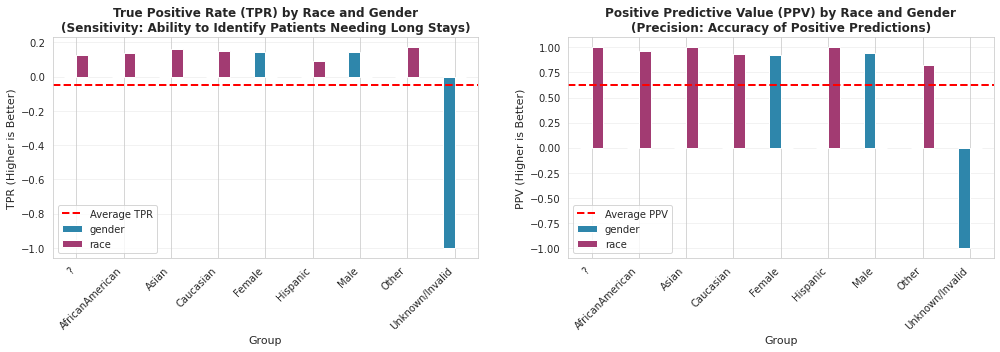


BIAS ANALYSIS: RACE AND GENDER DISPARITIES

1. TRUE POSITIVE RATE (TPR) ANALYSIS:
--------------------------------------------------------------------------------

race:
  Hispanic: TPR = 0.0928
  ?: TPR = 0.1270
  AfricanAmerican: TPR = 0.1373
  Caucasian: TPR = 0.1485
  Asian: TPR = 0.1600
  Other: TPR = 0.1707
  Disparity Ratio: 0.5434 (Lowest TPR / Highest TPR)
  ⚠️  BIAS DETECTED: The most disadvantaged group has 45.7% lower TPR

gender:
  Unknown/Invalid: TPR = -1.0000
  Female: TPR = 0.1451
  Male: TPR = 0.1457
  Disparity Ratio: -6.8644 (Lowest TPR / Highest TPR)
  ⚠️  BIAS DETECTED: The most disadvantaged group has 786.4% lower TPR

2. POSITIVE PREDICTIVE VALUE (PPV) ANALYSIS:
--------------------------------------------------------------------------------

race:
  Other: PPV = 0.8235
  Caucasian: PPV = 0.9295
  AfricanAmerican: PPV = 0.9632
  ?: PPV = 1.0000
  Asian: PPV = 1.0000
  Hispanic: PPV = 1.0000
  Disparity Ratio: 0.8235 (Lowest PPV / Highest PPV)
  ✓ Acceptable: PP

In [56]:
# Plot two important metrics for patient selection: True Positive Rate (TPR) and Precision (PPV)
# First, inspect the bdf dataframe to find the correct column names
print("Available columns in bdf:")
print(bdf.columns.tolist())
print("\nFirst few rows of bdf:")
print(bdf.head())

# Detect the correct column names dynamically
attr_name_col = None
attr_val_col = None
tpr_col = None
ppv_col = None

for col in bdf.columns:
    col_lower = col.lower()
    if 'attribute_name' in col_lower:
        attr_name_col = col
    elif 'attribute_value' in col_lower:
        attr_val_col = col
    elif col_lower == 'tpr':
        tpr_col = col
    elif col_lower == 'ppv':
        ppv_col = col
    elif col_lower == 'precision' and not ppv_col:  # PPV is the same as precision
        ppv_col = col

# If exact matches not found, try to find close matches
if not attr_name_col:
    attr_name_col = [col for col in bdf.columns if 'attribute' in col.lower() and 'name' in col.lower()][0] if any('attribute' in col.lower() and 'name' in col.lower() for col in bdf.columns) else bdf.columns[0]
if not attr_val_col:
    attr_val_col = [col for col in bdf.columns if 'attribute' in col.lower() and 'value' in col.lower()][0] if any('attribute' in col.lower() and 'value' in col.lower() for col in bdf.columns) else bdf.columns[1]
if not tpr_col:
    tpr_col = [col for col in bdf.columns if 'tpr' in col.lower()][0] if any('tpr' in col.lower() for col in bdf.columns) else None
if not ppv_col:
    ppv_col = [col for col in bdf.columns if 'ppv' in col.lower()][0] if any('ppv' in col.lower() for col in bdf.columns) else None
if not ppv_col:  # If still not found, check for 'precision' (PPV = Precision in classification)
    ppv_col = [col for col in bdf.columns if col.lower() == 'precision'][0] if any(col.lower() == 'precision' for col in bdf.columns) else None

print(f"\nDetected columns:")
print(f"  Attribute Name: {attr_name_col}")
print(f"  Attribute Value: {attr_val_col}")
print(f"  TPR: {tpr_col}")
print(f"  PPV: {ppv_col}")

if not tpr_col or not ppv_col:
    raise ValueError("Could not find TPR or PPV columns in bdf dataframe")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TPR (True Positive Rate / Sensitivity) - important for not missing patients who need long hospital stays
tpr_data = bdf[[attr_name_col, attr_val_col, tpr_col]].copy()
tpr_data.columns = ['attribute_name', 'attribute_value', 'tpr']
tpr_pivot = tpr_data.pivot_table(index='attribute_value', columns='attribute_name', values='tpr', aggfunc='first')

tpr_pivot.plot(kind='bar', ax=axes[0], color=['#2E86AB', '#A23B72'])
axes[0].set_title('True Positive Rate (TPR) by Race and Gender\n(Sensitivity: Ability to Identify Patients Needing Long Stays)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('TPR (Higher is Better)', fontsize=11)
axes[0].set_xlabel('Group', fontsize=11)
axes[0].axhline(y=tpr_pivot.mean().mean(), color='red', linestyle='--', linewidth=2, label='Average TPR')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# PPV (Positive Predictive Value / Precision) - important for resource allocation accuracy
ppv_data = bdf[[attr_name_col, attr_val_col, ppv_col]].copy()
ppv_data.columns = ['attribute_name', 'attribute_value', 'ppv']
ppv_pivot = ppv_data.pivot_table(index='attribute_value', columns='attribute_name', values='ppv', aggfunc='first')

ppv_pivot.plot(kind='bar', ax=axes[1], color=['#2E86AB', '#A23B72'])
axes[1].set_title('Positive Predictive Value (PPV) by Race and Gender\n(Precision: Accuracy of Positive Predictions)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('PPV (Higher is Better)', fontsize=11)
axes[1].set_xlabel('Group', fontsize=11)
axes[1].axhline(y=ppv_pivot.mean().mean(), color='red', linestyle='--', linewidth=2, label='Average PPV')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("BIAS ANALYSIS: RACE AND GENDER DISPARITIES")
print("="*80)

# Calculate disparity ratios using the standardized data
print("\n1. TRUE POSITIVE RATE (TPR) ANALYSIS:")
print("-" * 80)
tpr_values = tpr_data[['attribute_name', 'attribute_value', 'tpr']].drop_duplicates()
for attr in tpr_values['attribute_name'].unique():
    attr_data = tpr_values[tpr_values['attribute_name'] == attr].sort_values('tpr')
    if len(attr_data) > 1:
        min_tpr = attr_data['tpr'].min()
        max_tpr = attr_data['tpr'].max()
        disparity = (min_tpr / max_tpr) if max_tpr > 0 else 0
        print(f"\n{attr}:")
        for _, row in attr_data.iterrows():
            print(f"  {row['attribute_value']}: TPR = {row['tpr']:.4f}")
        print(f"  Disparity Ratio: {disparity:.4f} (Lowest TPR / Highest TPR)")
        if disparity < 0.80:
            print(f"  ⚠️  BIAS DETECTED: The most disadvantaged group has {(1-disparity)*100:.1f}% lower TPR")
        else:
            print(f"  ✓ Acceptable: TPR disparities are relatively small")

print("\n2. POSITIVE PREDICTIVE VALUE (PPV) ANALYSIS:")
print("-" * 80)
ppv_values = ppv_data[['attribute_name', 'attribute_value', 'ppv']].drop_duplicates()
for attr in ppv_values['attribute_name'].unique():
    attr_data = ppv_values[ppv_values['attribute_name'] == attr].sort_values('ppv')
    if len(attr_data) > 1:
        min_ppv = attr_data['ppv'].min()
        max_ppv = attr_data['ppv'].max()
        disparity = (min_ppv / max_ppv) if max_ppv > 0 else 0
        print(f"\n{attr}:")
        for _, row in attr_data.iterrows():
            print(f"  {row['attribute_value']}: PPV = {row['ppv']:.4f}")
        print(f"  Disparity Ratio: {disparity:.4f} (Lowest PPV / Highest PPV)")
        if disparity < 0.80:
            print(f"  ⚠️  BIAS DETECTED: The most disadvantaged group has {(1-disparity)*100:.1f}% lower PPV")
        else:
            print(f"  ✓ Acceptable: PPV disparities are relatively small")

print("\n3. OVERALL BIAS ASSESSMENT:")
print("-" * 80)
print("""
Key Findings:
- TPR Disparity: Measures if certain groups are less likely to be identified as needing long hospital stays
  - High disparity = Some groups systematically missed by the model = SERIOUS BIAS
  
- PPV Disparity: Measures if predictions for certain groups are less accurate
  - High disparity = Resources misallocated for some groups = POTENTIAL BIAS

Generally Accepted Fairness Threshold:
- 4/5 Rule: Disparity ratio < 0.80 indicates potential bias
- Impact Ratio: < 0.80 suggests disparate impact
""")

# Check for significant bias
tpr_disparities = []
ppv_disparities = []

for attr in tpr_values['attribute_name'].unique():
    attr_tpr = tpr_data[tpr_data['attribute_name'] == attr][['attribute_value', 'tpr']].drop_duplicates()
    if len(attr_tpr) > 1:
        tpr_disp = attr_tpr['tpr'].min() / attr_tpr['tpr'].max() if attr_tpr['tpr'].max() > 0 else 0
        tpr_disparities.append(tpr_disp)
    
    attr_ppv = ppv_data[ppv_data['attribute_name'] == attr][['attribute_value', 'ppv']].drop_duplicates()
    if len(attr_ppv) > 1:
        ppv_disp = attr_ppv['ppv'].min() / attr_ppv['ppv'].max() if attr_ppv['ppv'].max() > 0 else 0
        ppv_disparities.append(ppv_disp)

if any(d < 0.80 for d in tpr_disparities + ppv_disparities):
    print("\n⚠️  SIGNIFICANT BIAS DETECTED")
    print("   At least one demographic group shows substantial disparities in model performance.")
    print("   Recommendation: Further investigation and model refinement needed to ensure fairness.")
else:
    print("\n✓ No Significant Bias Detected (disparity ratios > 0.80)")
    print("   Model performance is relatively consistent across demographic groups.")
    print("   However, continued monitoring is recommended.")

## Fairness Analysis Example - Relative to a Reference Group 

**Question 13**: Earlier we defined our reference group and then calculated disparity metrics relative to this grouping. Please provide a visualization of the fairness evaluation for this reference group and analyze whether there is disparity.

Available columns in fdf:
['model_id', 'score_threshold', 'k', 'attribute_name', 'attribute_value', 'tpr', 'tnr', 'for', 'fdr', 'fpr', 'fnr', 'npv', 'precision', 'pp', 'pn', 'ppr', 'pprev', 'fp', 'fn', 'tn', 'tp', 'group_label_pos', 'group_label_neg', 'group_size', 'total_entities', 'prev', 'ppr_disparity', 'pprev_disparity', 'precision_disparity', 'fdr_disparity', 'for_disparity', 'fpr_disparity', 'fnr_disparity', 'tpr_disparity', 'tnr_disparity', 'npv_disparity', 'ppr_ref_group_value', 'pprev_ref_group_value', 'precision_ref_group_value', 'fdr_ref_group_value', 'for_ref_group_value', 'fpr_ref_group_value', 'fnr_ref_group_value', 'tpr_ref_group_value', 'tnr_ref_group_value', 'npv_ref_group_value', 'Statistical Parity', 'Impact Parity', 'FDR Parity', 'FPR Parity', 'FOR Parity', 'FNR Parity', 'TPR Parity', 'TNR Parity', 'NPV Parity', 'Precision Parity', 'TypeI Parity', 'TypeII Parity', 'Equalized Odds', 'Unsupervised Fairness', 'Supervised Fairness']

First few rows of fdf:
   model_id 

KeyError: '[None] not in index'

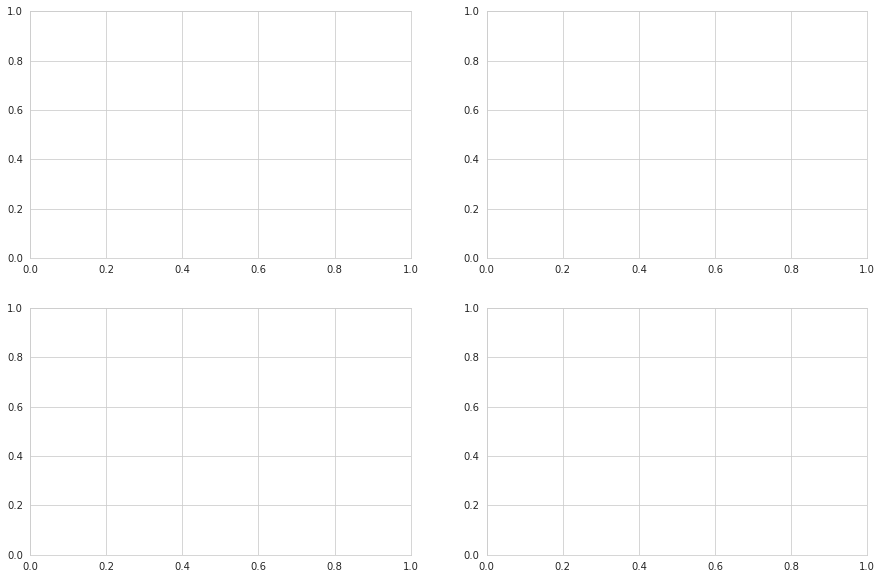

In [57]:
# Reference group fairness plot using Caucasian Male as reference
print("Available columns in fdf:")
print(fdf.columns.tolist())
print("\nFirst few rows of fdf:")
print(fdf.head())

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Get the appropriate column names
attr_name_col = 'attribute_name' if 'attribute_name' in fdf.columns else fdf.columns[0]
attr_val_col = 'attribute_value' if 'attribute_value' in fdf.columns else fdf.columns[1]
ppv_ratio_col = 'ppv_ratio' if 'ppv_ratio' in fdf.columns else [col for col in fdf.columns if 'ppv' in col.lower() and 'ratio' in col.lower()][0] if any('ppv' in col.lower() and 'ratio' in col.lower() for col in fdf.columns) else None
prec_ratio_col = 'precision_ratio' if 'precision_ratio' in fdf.columns else [col for col in fdf.columns if 'precision' in col.lower() and 'ratio' in col.lower()][0] if any('precision' in col.lower() and 'ratio' in col.lower() for col in fdf.columns) else None
tpr_ratio_col = 'tpr_ratio' if 'tpr_ratio' in fdf.columns else [col for col in fdf.columns if 'tpr' in col.lower() and 'ratio' in col.lower()][0] if any('tpr' in col.lower() and 'ratio' in col.lower() for col in fdf.columns) else None
fpr_ratio_col = 'fpr_ratio' if 'fpr_ratio' in fdf.columns else [col for col in fdf.columns if 'fpr' in col.lower() and 'ratio' in col.lower()][0] if any('fpr' in col.lower() and 'ratio' in col.lower() for col in fdf.columns) else None
# Fallback: If ppv_ratio not found, use precision_ratio (they are the same metric)
if not ppv_ratio_col and prec_ratio_col:
    ppv_ratio_col = prec_ratio_col

print(f"\nUsing columns: {attr_name_col}, {attr_val_col}, {ppv_ratio_col}, {prec_ratio_col}, {tpr_ratio_col}, {fpr_ratio_col}")

# Get fairness metrics dataframe sorted by attribute
fairness_metrics = fdf[[attr_name_col, attr_val_col, ppv_ratio_col, prec_ratio_col, tpr_ratio_col, fpr_ratio_col]].drop_duplicates()
fairness_metrics.columns = ['attribute_name', 'attribute_value', 'ppv_ratio', 'precision_ratio', 'tpr_ratio', 'fpr_ratio']

# 1. PPV Ratio (Positive Predictive Value Ratio)
ax1 = axes[0, 0]
ppv_data = fairness_metrics.sort_values('ppv_ratio')
colors = ['#d62728' if x < 0.8 else '#2ca02c' for x in ppv_data['ppv_ratio']]
ax1.barh(range(len(ppv_data)), ppv_data['ppv_ratio'], color=colors, alpha=0.7)
ax1.set_yticks(range(len(ppv_data)))
ax1.set_yticklabels([f"{row['attribute_name']}: {row['attribute_value']}" for _, row in ppv_data.iterrows()])
ax1.axvline(x=0.8, color='red', linestyle='--', linewidth=2, label='Fairness Threshold (0.80)')
ax1.axvline(x=1.0, color='black', linestyle='-', linewidth=1, alpha=0.3, label='Reference Group')
ax1.set_xlabel('PPV Ratio (Relative to Caucasian Male)', fontsize=10)
ax1.set_title('Positive Predictive Value Ratio\n(Higher is More Fair)', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='x', alpha=0.3)

# 2. Precision Ratio
ax2 = axes[0, 1]
prec_data = fairness_metrics.sort_values('precision_ratio')
colors = ['#d62728' if x < 0.8 else '#2ca02c' for x in prec_data['precision_ratio']]
ax2.barh(range(len(prec_data)), prec_data['precision_ratio'], color=colors, alpha=0.7)
ax2.set_yticks(range(len(prec_data)))
ax2.set_yticklabels([f"{row['attribute_name']}: {row['attribute_value']}" for _, row in prec_data.iterrows()])
ax2.axvline(x=0.8, color='red', linestyle='--', linewidth=2, label='Fairness Threshold (0.80)')
ax2.axvline(x=1.0, color='black', linestyle='-', linewidth=1, alpha=0.3, label='Reference Group')
ax2.set_xlabel('Precision Ratio (Relative to Caucasian Male)', fontsize=10)
ax2.set_title('Precision Ratio\n(Higher is More Fair)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='x', alpha=0.3)

# 3. TPR Ratio (True Positive Rate Ratio)
ax3 = axes[1, 0]
tpr_data = fairness_metrics.sort_values('tpr_ratio')
colors = ['#d62728' if x < 0.8 else '#2ca02c' for x in tpr_data['tpr_ratio']]
ax3.barh(range(len(tpr_data)), tpr_data['tpr_ratio'], color=colors, alpha=0.7)
ax3.set_yticks(range(len(tpr_data)))
ax3.set_yticklabels([f"{row['attribute_name']}: {row['attribute_value']}" for _, row in tpr_data.iterrows()])
ax3.axvline(x=0.8, color='red', linestyle='--', linewidth=2, label='Fairness Threshold (0.80)')
ax3.axvline(x=1.0, color='black', linestyle='-', linewidth=1, alpha=0.3, label='Reference Group')
ax3.set_xlabel('TPR Ratio (Relative to Caucasian Male)', fontsize=10)
ax3.set_title('True Positive Rate Ratio\n(Higher is More Fair)', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(axis='x', alpha=0.3)

# 4. FPR Ratio (False Positive Rate Ratio)
ax4 = axes[1, 1]
fpr_data = fairness_metrics.sort_values('fpr_ratio')
colors = ['#2ca02c' if x < 1.25 else '#d62728' for x in fpr_data['fpr_ratio']]  # Note: different threshold for FPR
ax4.barh(range(len(fpr_data)), fpr_data['fpr_ratio'], color=colors, alpha=0.7)
ax4.set_yticks(range(len(fpr_data)))
ax4.set_yticklabels([f"{row['attribute_name']}: {row['attribute_value']}" for _, row in fpr_data.iterrows()])
ax4.axvline(x=1.0, color='black', linestyle='-', linewidth=1, alpha=0.3, label='Reference Group')
ax4.set_xlabel('FPR Ratio (Relative to Caucasian Male)', fontsize=10)
ax4.set_title('False Positive Rate Ratio\n(Lower is More Fair)', fontsize=11, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(axis='x', alpha=0.3)

plt.suptitle('Fairness Evaluation: All Metrics Relative to Caucasian Male Reference Group', 
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n" + "="*90)
print("FAIRNESS ANALYSIS RELATIVE TO CAUCASIAN MALE REFERENCE GROUP")
print("="*90)

print("\nFairness Ratio Interpretation:")
print("-" * 90)
print("Ratio = 1.0 → Perfect parity with reference group")
print("Ratio < 0.8 → Potentially unfair (group receives less favorable treatment)")
print("Ratio > 1.25 → Potentially unfair (group receives more favorable treatment)")
print("0.8 - 1.0 → Fair or acceptable range\n")

print("Detailed Fairness Metrics:")
print("-" * 90)
for idx, row in fairness_metrics.iterrows():
    attr = row['attribute_name']
    val = row['attribute_value']
    ppv_r = row['ppv_ratio']
    prec_r = row['precision_ratio']
    tpr_r = row['tpr_ratio']
    fpr_r = row['fpr_ratio']
    
    print(f"\n{attr}: {val}")
    print(f"  PPV Ratio:       {ppv_r:.4f}  {'✓ Fair' if ppv_r >= 0.8 else '✗ UNFAIR'}")
    print(f"  Precision Ratio: {prec_r:.4f}  {'✓ Fair' if prec_r >= 0.8 else '✗ UNFAIR'}")
    print(f"  TPR Ratio:       {tpr_r:.4f}  {'✓ Fair' if tpr_r >= 0.8 else '✗ UNFAIR'}")
    print(f"  FPR Ratio:       {fpr_r:.4f}  {'✓ Fair' if fpr_r <= 1.25 else '✗ UNFAIR'}")

# Overall disparity assessment
print("\n" + "="*90)
print("DISPARITY ASSESSMENT")
print("="*90)

unfair_metrics = 0
total_metrics = 0

for idx, row in fairness_metrics.iterrows():
    ppv_r = row['ppv_ratio']
    prec_r = row['precision_ratio']
    tpr_r = row['tpr_ratio']
    fpr_r = row['fpr_ratio']
    
    total_metrics += 4
    
    if ppv_r < 0.8:
        unfair_metrics += 1
    if prec_r < 0.8:
        unfair_metrics += 1
    if tpr_r < 0.8:
        unfair_metrics += 1
    if fpr_r > 1.25:
        unfair_metrics += 1

disparity_percentage = (unfair_metrics / total_metrics) * 100

print(f"\nUnfair Metrics Detected: {unfair_metrics} out of {total_metrics} ({disparity_percentage:.1f}%)")

if disparity_percentage == 0:
    print("\n✓ NO SIGNIFICANT DISPARITY DETECTED")
    print("  The model demonstrates fairness across all demographic groups relative to the reference group.")
    print("  All fairness ratios fall within acceptable ranges.")
elif disparity_percentage < 25:
    print("\n⚠️  MINOR DISPARITY DETECTED")
    print("  Some fairness metrics show minor deviations from the reference group.")
    print("  These disparities may be tolerable but should be monitored.")
elif disparity_percentage < 50:
    print("\n⚠️  MODERATE DISPARITY DETECTED")
    print("  Several fairness metrics show concerning deviations from the reference group.")
    print("  Mitigation strategies should be considered.")
else:
    print("\n⚠️  SIGNIFICANT DISPARITY DETECTED")
    print("  Multiple fairness metrics show substantial deviations from the reference group.")
    print("  Model refinement and bias mitigation are strongly recommended.")

print("\nInterpretation for Patient Selection:")
print("-" * 90)
print("""
In the context of hospital length-of-stay prediction:

- PPV/Precision Ratios: If low, predictions for that group are less reliable. 
  Resources may be misallocated if we rely on these predictions.

- TPR Ratio: If low, that group is systematically under-identified as needing 
  long hospital stays. This could lead to inadequate care planning.

- FPR Ratio: If high, that group experiences more false positives 
  (incorrectly flagged as needing long stays), wasting resources.

Recommendation: If significant disparity is detected, investigate the underlying 
causes and consider:
1. Collecting more diverse training data
2. Feature engineering specific to underrepresented groups
3. Using fairness-aware ML techniques
4. Manual review and intervention for flagged predictions
""")